## Setup Dependencies

In [129]:
pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [130]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import requests
import json

In [131]:
import folium
import requests
import json

# URL of the GeoJSON file
url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"

# Fetch the GeoJSON data
response = requests.get(url)
geojson_data = json.loads(response.text)

# Create a map centered on Europe
m = folium.Map(location=[50, 10], zoom_start=4)

# Add the GeoJSON data to the map
folium.GeoJson(
    geojson_data,
    style_function=lambda feature: {
        'fillColor': '#ffff00',
        'color': 'black',
        'weight': 2,
        'fillOpacity': 0.5,
    }
).add_to(m)

# Save the map to an HTML file
m.save('europe_map.html')

print("Map saved as europe_map.html")

Map saved as europe_map.html


In [132]:
price_and_purity_excel_file = './data/raw/8.1._Prices_and_purities_of_drugs.xlsx'
seizures_excel_file = './data/raw/7.1._Drug_seizures_2018-2022.xlsx'


prices_output_dir = './data/clean/prices'
purities_output_dir = './data/clean/purities'
seizures_output_dir = './data/clean/seizures'

In [133]:
sheets = pd.read_excel(price_and_purity_excel_file, sheet_name=None)
for key in sheets.keys():
    print(key)
sheets = pd.read_excel(seizures_excel_file, sheet_name=None)
for key in sheets.keys():
    print(key)

Prices in USD
Purities
Export


## Read In Data


## Prices

In [134]:
drug_prices_df = pd.read_excel(price_and_purity_excel_file, 
                   sheet_name='Prices in USD',
                   header=1,
                   usecols="A:L"
                   )
drug_prices_df.head()

,Region,SubRegion,Country/Territory,DrugGroup,Drug,Specify,LevelOfSale,Year,Typical_USD,Minimum_USD,Maximum_USD,Unit
0,Africa,East Africa,Kenya,Amphetamine-type stimulants,Methamphetamine powder,NaN,Retail,2022,68.077574,NaN,NaN,Grams
1,Africa,East Africa,Kenya,Cannabis-type drugs,Cannabis herb (marijuana),NaN,Retail,2022,255.290904,NaN,NaN,Kilograms
2,Africa,East Africa,Kenya,Cocaine-type drugs,Cocaine hydrochloride,NaN,Retail,2022,51.058181,NaN,NaN,Grams
3,Africa,East Africa,Kenya,Opioids,Heroin,NaN,Retail,2022,34.038787,NaN,NaN,Grams
4,Africa,East Africa,Kenya,Amphetamine-type stimulants,Methamphetamine powder,NaN,Retail,2021,73120.127229,NaN,NaN,Kilograms


In [135]:
drug_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4646 entries, 0 to 4645
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Region             4646 non-null   object 
 1   SubRegion          4646 non-null   object 
 2   Country/Territory  4646 non-null   object 
 3   DrugGroup          4646 non-null   object 
 4   Drug               4646 non-null   object 
 5   Specify            328 non-null    object 
 6   LevelOfSale        4646 non-null   object 
 7   Year               4646 non-null   int64  
 8   Typical_USD        3735 non-null   float64
 9   Minimum_USD        3544 non-null   float64
 10  Maximum_USD        3580 non-null   float64
 11  Unit               4580 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 435.7+ KB


## Purities

In [136]:
drug_purity_df = pd.read_excel(price_and_purity_excel_file, 
                   sheet_name='Purities',
                   header=1,
                   usecols="A:L"
                   )
drug_purity_df.head()

,Region,SubRegion,Country/Territory,LevelOfSale,DrugGroup,Drug,Specify,Year,Typical,Minimum,Maximum,Measurement
0,Africa,East Africa,Kenya,Wholesale,Opioids,Heroin,NaN,2020,39.00,35.00,42.00,% (percent)
1,Africa,East Africa,Kenya,Retail,Cocaine-type,Cocaine salts,NaN,2019,0.10,0.05,0.15,% (percent)
2,Africa,East Africa,Kenya,Retail,Opioids,Heroin,Brown,2019,0.10,0.05,0.15,% (percent)
3,Africa,East Africa,Kenya,Wholesale,Cocaine-type,Cocaine salts,NaN,2019,0.15,0.25,0.30,% (percent)
4,Africa,East Africa,Kenya,Wholesale,Opioids,Heroin,Brown,2019,0.25,0.30,0.60,% (percent)


In [137]:
drug_purity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Region             1658 non-null   object 
 1   SubRegion          1658 non-null   object 
 2   Country/Territory  1658 non-null   object 
 3   LevelOfSale        1658 non-null   object 
 4   DrugGroup          1658 non-null   object 
 5   Drug               1658 non-null   object 
 6   Specify            82 non-null     object 
 7   Year               1658 non-null   int64  
 8   Typical            1441 non-null   float64
 9   Minimum            1415 non-null   float64
 10  Maximum            1432 non-null   float64
 11  Measurement        1597 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 155.6+ KB


## Seizres

In [138]:
drug_seizures_df = pd.read_excel(seizures_excel_file, 
                   sheet_name='Export',
                   header=1,
                   usecols="A:I"
                   )
drug_seizures_df.head()

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode
0,Africa,East Africa,Kenya,Amphetamine-type stimulants (excluding “ecstasy”),Methamphetamine,Methamphetamine,2022,10.84,KEN
1,Africa,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2022,8474.41,KEN
2,Africa,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis plants,Cannabis plants,2022,2534.40,KEN
3,Africa,East Africa,Kenya,Cocaine-type,Cocaine,Cocaine hydrochloride,2022,10.99,KEN
4,Africa,East Africa,Kenya,Opioids,Opiates,Heroin,2022,38.94,KEN


In [139]:
drug_seizures_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11013 entries, 0 to 11012
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          11013 non-null  object 
 1   SubRegion       11013 non-null  object 
 2   Country         11013 non-null  object 
 3   DrugGroup       11013 non-null  object 
 4   DrugSubGroup    11013 non-null  object 
 5   DrugName        11013 non-null  object 
 6   Reference year  11013 non-null  int64  
 7   Kilograms       10941 non-null  float64
 8   msCode          11013 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 774.5+ KB


## Clean and Filter Data

## Unify Column Names

In [140]:
drug_prices_df = drug_prices_df.rename(columns={'Country/Territory':'Country'})
drug_purity_df = drug_purity_df.rename(columns={'Country/Territory':'Country'})
drug_seizures_df = drug_seizures_df.rename(columns={'Reference year':'Year'})

## Filter Region to Europe

In [141]:
region = 'Europe'
drug_seizures_df = drug_seizures_df[drug_seizures_df['Region'] == region].reset_index(drop=True)
drug_prices_df = drug_prices_df[drug_prices_df['Region'] == region].reset_index(drop=True)
drug_purity_df = drug_purity_df[drug_purity_df['Region'] == region].reset_index(drop=True)

## Classify Substances
get rid of inconsistent drug grouping, classification will also reduce to a smaller/broader selection of drugs/substances.

In [142]:
drug_prices_df['DrugGroup'].unique()

array(['“Ecstasy”-type substances', 'Amphetamine-type stimulants',
       'Cannabis-type drugs', 'Cocaine-type drugs', 'Hallucinogens',
       'NPS', 'Opioids', 'ATS', 'Cannabis-type', 'Cocaine-type',
       'Substances not under international control',
       'Other miscellaneous', 'Any other drugs/substances',
       'Sedatives and Tranquillizers',
       'Cannabis-type drugs (excluding synthetic cannabinoids)',
       'Sedatives and tranquilizers (please specify)',
       'Amphetamine-type stimulants (excluding “ecstasy”)', 'Precursors'],
      dtype=object)

In [143]:
drug_purity_df['DrugGroup'].unique()

array(['Opioids', '“Ecstasy”-type substances',
       'Amphetamine-type stimulants', 'Cannabis-type drugs',
       'Cocaine-type drugs', 'Hallucinogens', 'Cannabis-type',
       'Cocaine-type', 'ATS',
       'Sedatives and tranquilizers (please specify)',
       'Sedatives and Tranquillizers'], dtype=object)

In [144]:
drug_seizures_df['DrugGroup'].unique()

array(['“Ecstasy”-type substances',
       'Amphetamine-type stimulants (excluding “ecstasy”)',
       'Cannabis-type drugs (excluding synthetic cannabinoids)',
       'Cocaine-type', 'Hallucinogens', 'Opioids', 'NPS',
       'Sedatives and tranquillizers', 'Precursors',
       'Any other drugs/substances', 'Solvents and Inhalants'],
      dtype=object)

In [145]:
def classify_substances(x:str):
    if x in ['Amphetamine-type stimulants', 'Amphetamine-type stimulants (excluding “ecstasy”)']:
        return 'Amphetamines'
    elif x in ['Cannabis-type', 'Cannabis-type drugs', 'Cannabis-type drugs (excluding synthetic cannabinoids)']:
        return 'Cannabis'
    elif x in ['Cocaine-type', 'Cocaine-type drugs']:
        return 'Cocaine'
    elif x in ['Sedatives and Tranquillizers', 'Sedatives and tranquilizers (please specify)', 'Sedatives and tranquillizers']:
        return 'Tranquillizers and Sedatives'
    elif x in '“Ecstasy”-type substances':
        return 'Ecstasy'
    elif x in 'Opioids':
        return 'Opioids'
    return 'Other'

In [146]:
drug_seizures_df['Substance'] = drug_seizures_df['DrugGroup'].apply(lambda x: classify_substances(x))
drug_prices_df['Substance'] = drug_prices_df['DrugGroup'].apply(lambda x: classify_substances(x))
drug_purity_df['Substance'] = drug_purity_df['DrugGroup'].apply(lambda x: classify_substances(x))

## Unify Country Names
Visualization later requires unique names for countries

In [147]:
url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)

df_countries = set(drug_prices_df['Country'].unique())
geojson_countries = set(europe_gdf['NAME'])
missing_in_geojson = df_countries - geojson_countries

print("Countries in your dataframe not found in GeoJSON:")
print(missing_in_geojson)

missing_in_df = geojson_countries - df_countries
print("\nCountries in GeoJSON not found in your dataframe:")
print(missing_in_df)

print("\nAll country names in GeoJSON:")
print(sorted(geojson_countries))

Countries in your dataframe not found in GeoJSON:
{'North Macedonia', 'Türkiye', 'Czechia', 'Gibraltar', 'Russian Federation'}

Countries in GeoJSON not found in your dataframe:
{'Switzerland', 'San Marino', 'Norway', 'The former Yugoslav Republic of Macedonia', 'Turkey', 'Faroe Islands', 'Monaco', 'Azerbaijan', 'Czech Republic', 'Georgia', 'Holy See (Vatican City)', 'Israel', 'Russia', 'Armenia'}

All country names in GeoJSON:
['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Faroe Islands', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Holy See (Vatican City)', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Monaco', 'Montenegro', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Republic of Moldova', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Swe

In [148]:
# {'Czech Republic', 'The former Yugoslav Republic of Macedonia', 'Russia', 'Israel', 'Faroe Islands', 'Armenia', 'Holy See (Vatican City)', 'Monaco', 'San Marino', 'Switzerland', 'Turkey', 'Azerbaijan', 'Norway', 'Georgia'}
# {'Russian Federation', 'Czechia', 'Gibraltar', 'Türkiye', 'North Macedonia'}
def rename_countries(x:str):
    if x in 'Russian Federation':
        return 'Russia'
    elif x in 'North Macedonia':
        return 'The former Yugoslav Republic of Macedonia'
    elif x in 'Czechia':
        return 'Czech Republic'
    elif x in 'Türkiye':
        return 'Turkey'
    else:
        return x

In [149]:
drug_seizures_df['Country'] = drug_seizures_df['Country'].apply(lambda x:rename_countries(x))
drug_prices_df['Country'] = drug_prices_df['Country'].apply(lambda x:rename_countries(x))
drug_purity_df['Country'] = drug_purity_df['Country'].apply(lambda x:rename_countries(x))

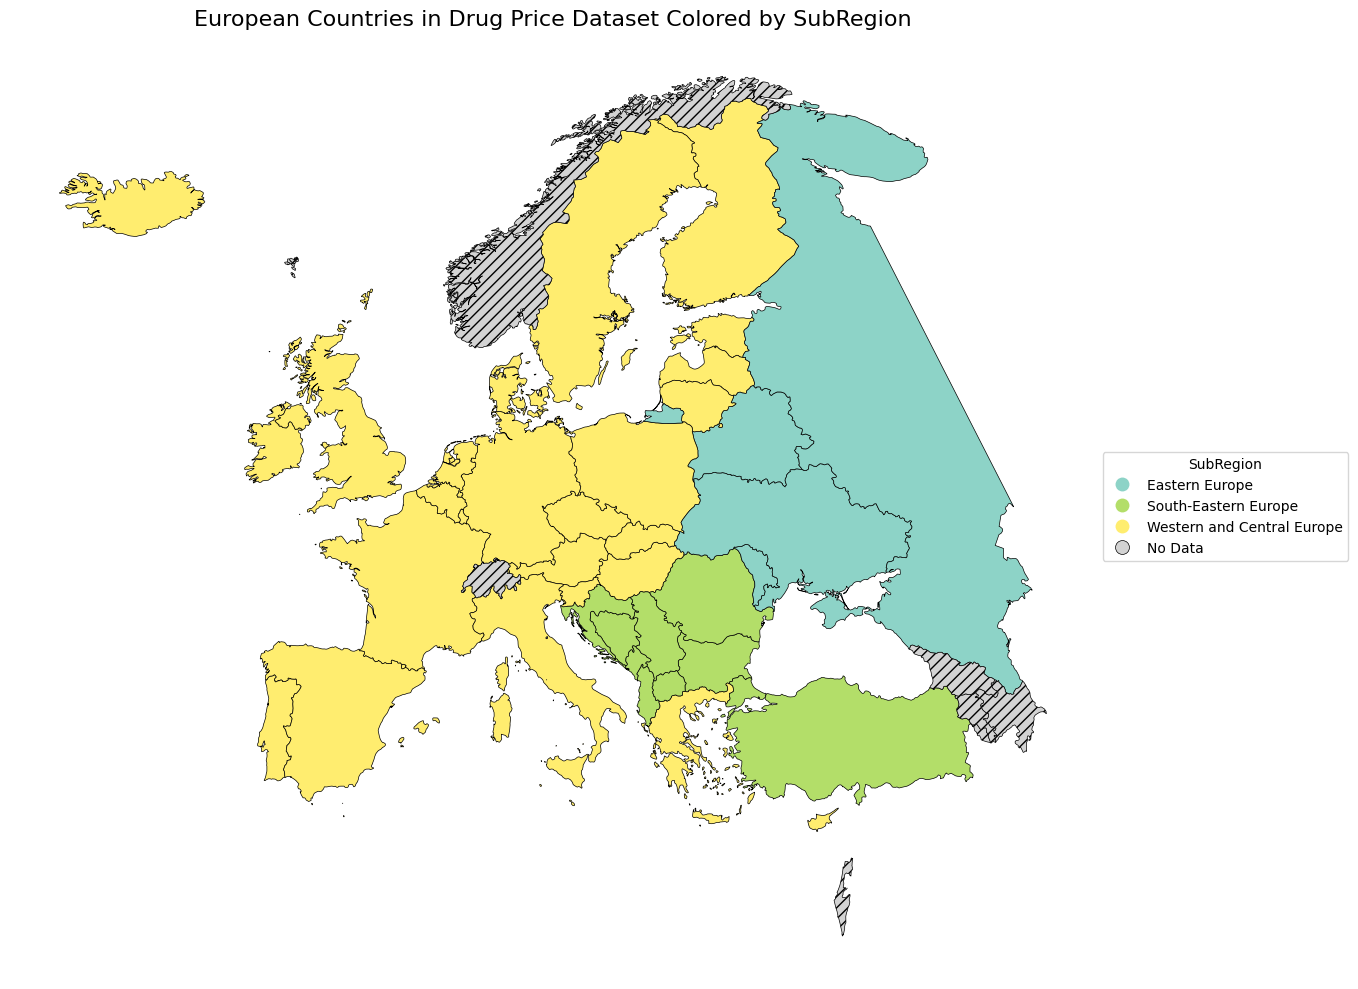

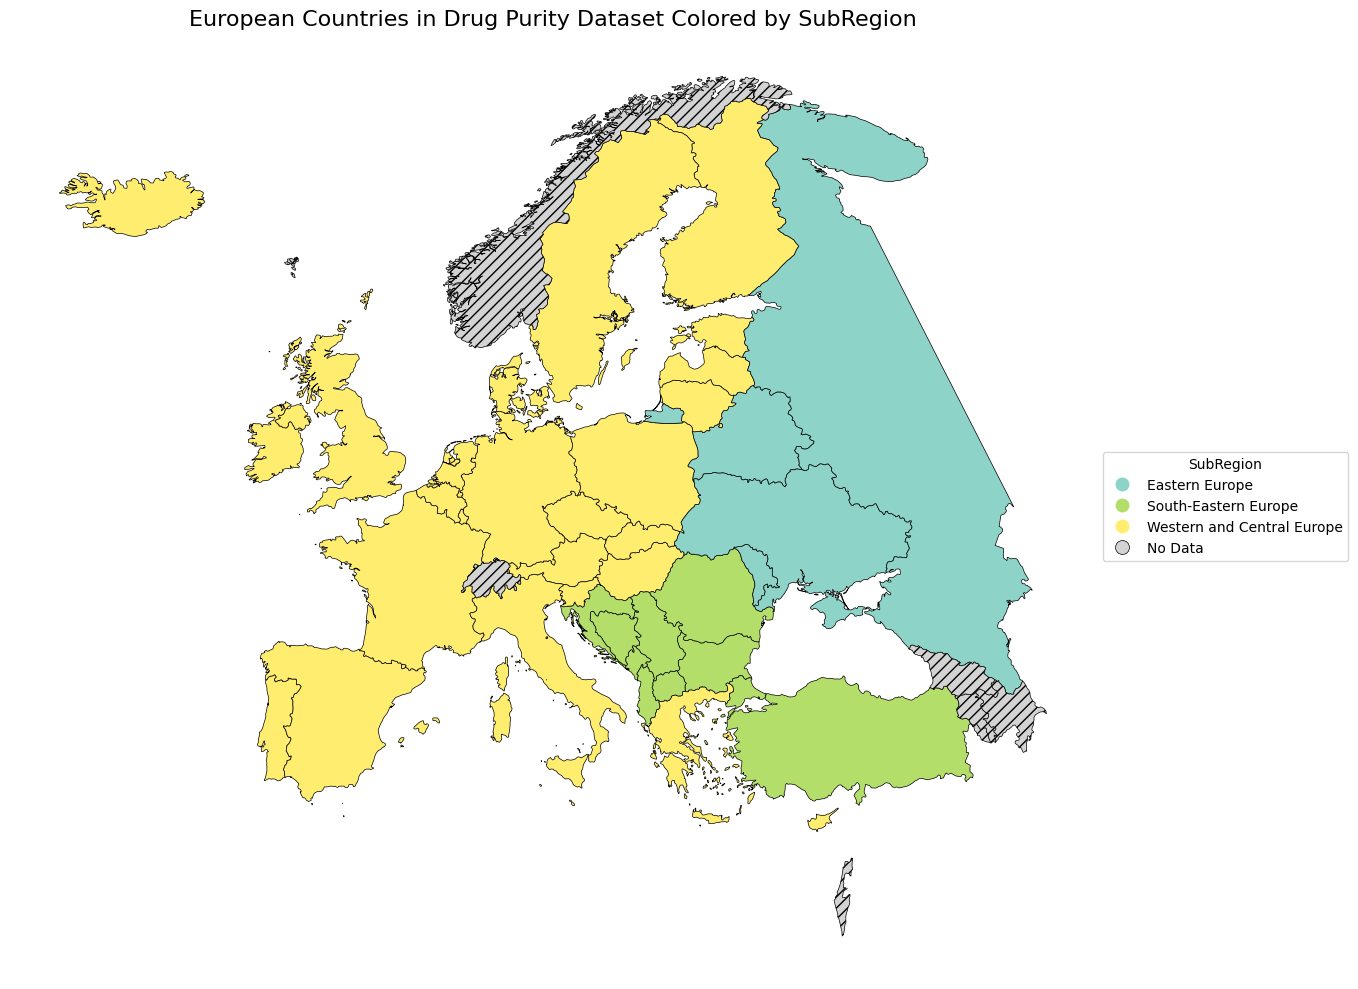

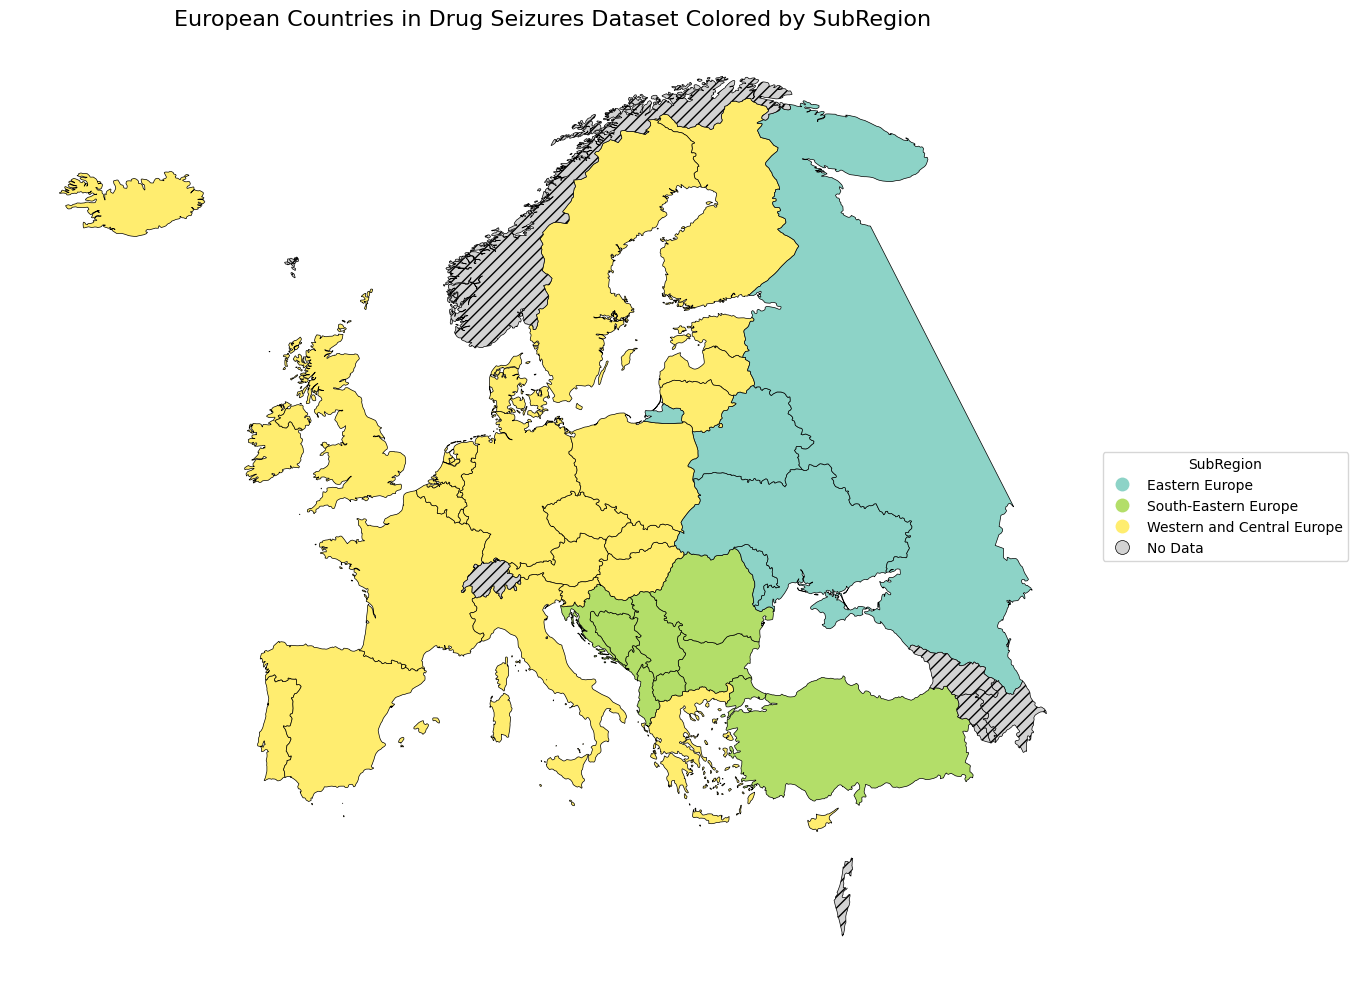

In [150]:
url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)

def plot_european(df:pd.DataFrame, title:str):
    subregion_data = df[['Country', 'SubRegion']].drop_duplicates()

    europe_subregions = europe_gdf.merge(subregion_data, how='left', left_on='NAME', right_on='Country')

    fig, ax = plt.subplots(1, 1, figsize=(15, 10))

    cmap = 'Set3'  

    europe_subregions.plot(column='SubRegion', ax=ax, legend=True,
                        legend_kwds={'title': 'SubRegion', 'loc': 'center left', 'bbox_to_anchor': (1, 0.5)},
                        missing_kwds={'color': 'lightgrey', 'edgecolor': 'black', 'hatch': '///', 'label': 'No Data'},
                        cmap=cmap,
                        edgecolor='black', linewidth=0.5)
    
    ax.axis('off')
    ax.set_title(title, fontsize=16)

    plt.tight_layout()
    plt.show()
plot_european(drug_prices_df, 'European Countries in Drug Price Dataset Colored by SubRegion')
plot_european(drug_prices_df, 'European Countries in Drug Purity Dataset Colored by SubRegion')
plot_european(drug_prices_df, 'European Countries in Drug Seizures Dataset Colored by SubRegion')

it can be seen that the different dataset cover the same countries

## Unify Prices per Unit
to be able to compare prices of different substances and be able to correctly sum them up for aggregation, they need to be transformed 

In [151]:
drug_prices_df['Unit'].unique()

array(['Grams', 'Units', 'Millilitres', 'Tablets', 'Tablet', 'Gram',
       'Kilograms', 'Kilogram', 'Dose', nan, 'Unit', 'Litres',
       '1000 tablets', 'Millilitre', '1000 units', '5 gram', 'Pill',
       'Mark', 'Stamp', 'Blotting paper', '10 gram', 'Litre', 'Trip',
       '10000 tablets', '100 unit', '10 units', '100 gram', 'Plasters',
       '100 milligram', 'Ounce'], dtype=object)

In [152]:
drug_prices_df = drug_prices_df.dropna(subset='Unit')

In [153]:
# price columns: 'Typical_USD', 'Minimum_USD', 'Maximum_USD'
# 'Grams', 'Gram', 'Kilograms', 'Kilogram', '100 milligram', '5 gram', '10 gram', '100 gram' => Gram
# 'Millilitres', 'Litres', 'Millilitre', 'Litre', 'Ounce' => Millilitre
# 'Tablets', 'Tablet', 'Units', 'Unit', '1000 tablets', '1000 units', 'Pill', 'Dose', '10000 tablets', '100 unit', 'Plasters' => Piece

import re

def extract_number_from_unit(unit_str):
    if pd.isna(unit_str):
        return 1
    match = re.search(r'(\d+)', str(unit_str))
    return int(match.group(1)) if match else 1

def unify_prices(df: pd.DataFrame):
    res = df.copy()
    price_cols = ['Typical_USD', 'Minimum_USD', 'Maximum_USD']
    
    # handle first part eg. 1 or 5
    res['unit_multiplier'] = res['Unit'].apply(extract_number_from_unit)
    
    unit_conversion = {
        'Kilograms': 1000,
        'Kilogram': 1000,
        'Litres': 1000,
        'Litre': 1000,
        'milligram': 1/1000,
        'Ounce': 29.5735
    }
    
    # get unit conversion multiplier
    res['conversion_multiplier'] = res['Unit'].map(lambda x: unit_conversion.get(str(x), 1))
    
    # apply both multipliers to price columns
    total_multiplier = res['unit_multiplier'] * res['conversion_multiplier']
    for col in price_cols:
        if col in res.columns:
            res[col] = res[col] / total_multiplier
    
    # drop temporary columns
    res = res.drop(['unit_multiplier', 'conversion_multiplier'], axis=1)
    
    return res

drug_prices_df = unify_prices(drug_prices_df)

In [154]:
def unify_unit_names(df: pd.DataFrame):
    res = df.copy()

    unit_mapping = {
        # Gram based units
        'Grams': 'Gram',
        'Gram': 'Gram',
        'Kilograms': 'Gram',
        'Kilogram': 'Gram',
        '5 gram': 'Gram',
        '10 gram': 'Gram',
        '100 gram': 'Gram',
        '100 milligram': 'Gram',
        
        # Millilitre based units
        'Millilitres': 'Millilitre',
        'Litres': 'Millilitre',
        'Millilitre': 'Millilitre',
        'Litre': 'Millilitre',
        'Ounce': 'Millilitre',
        
        # Piece based (to not get confused with the double meaning of Unit)
        'Tablets': 'Piece',
        'Tablet': 'Piece',
        'Units': 'Piece',
        'Unit': 'Piece',
        '1000 tablets': 'Piece',
        '1000 units': 'Piece',
        'Pill': 'Piece',
        'Dose': 'Piece',
        '10000 tablets': 'Piece',
        '100 unit': 'Piece',
        '10 units': 'Piece',
        'Plasters': 'Piece',
        'Mark': 'Piece',
        'Stamp': 'Piece',
        'Blotting paper': 'Piece',
        'Trip': 'Piece',
        
    }
    
    res['Unit'] = res['Unit'].replace(unit_mapping)
    
    return res
drug_prices_df = unify_unit_names(drug_prices_df)

In [155]:
drug_prices_df[['Substance','Unit']].drop_duplicates().sort_values(['Substance']).reset_index(drop=True)

,Substance,Unit
0,Amphetamines,Gram
1,Amphetamines,Piece
2,Cannabis,Gram
3,Cannabis,Millilitre
4,Cannabis,Piece
5,Cocaine,Millilitre
6,Cocaine,Gram
7,Cocaine,Piece
8,Ecstasy,Millilitre
9,Ecstasy,Gram


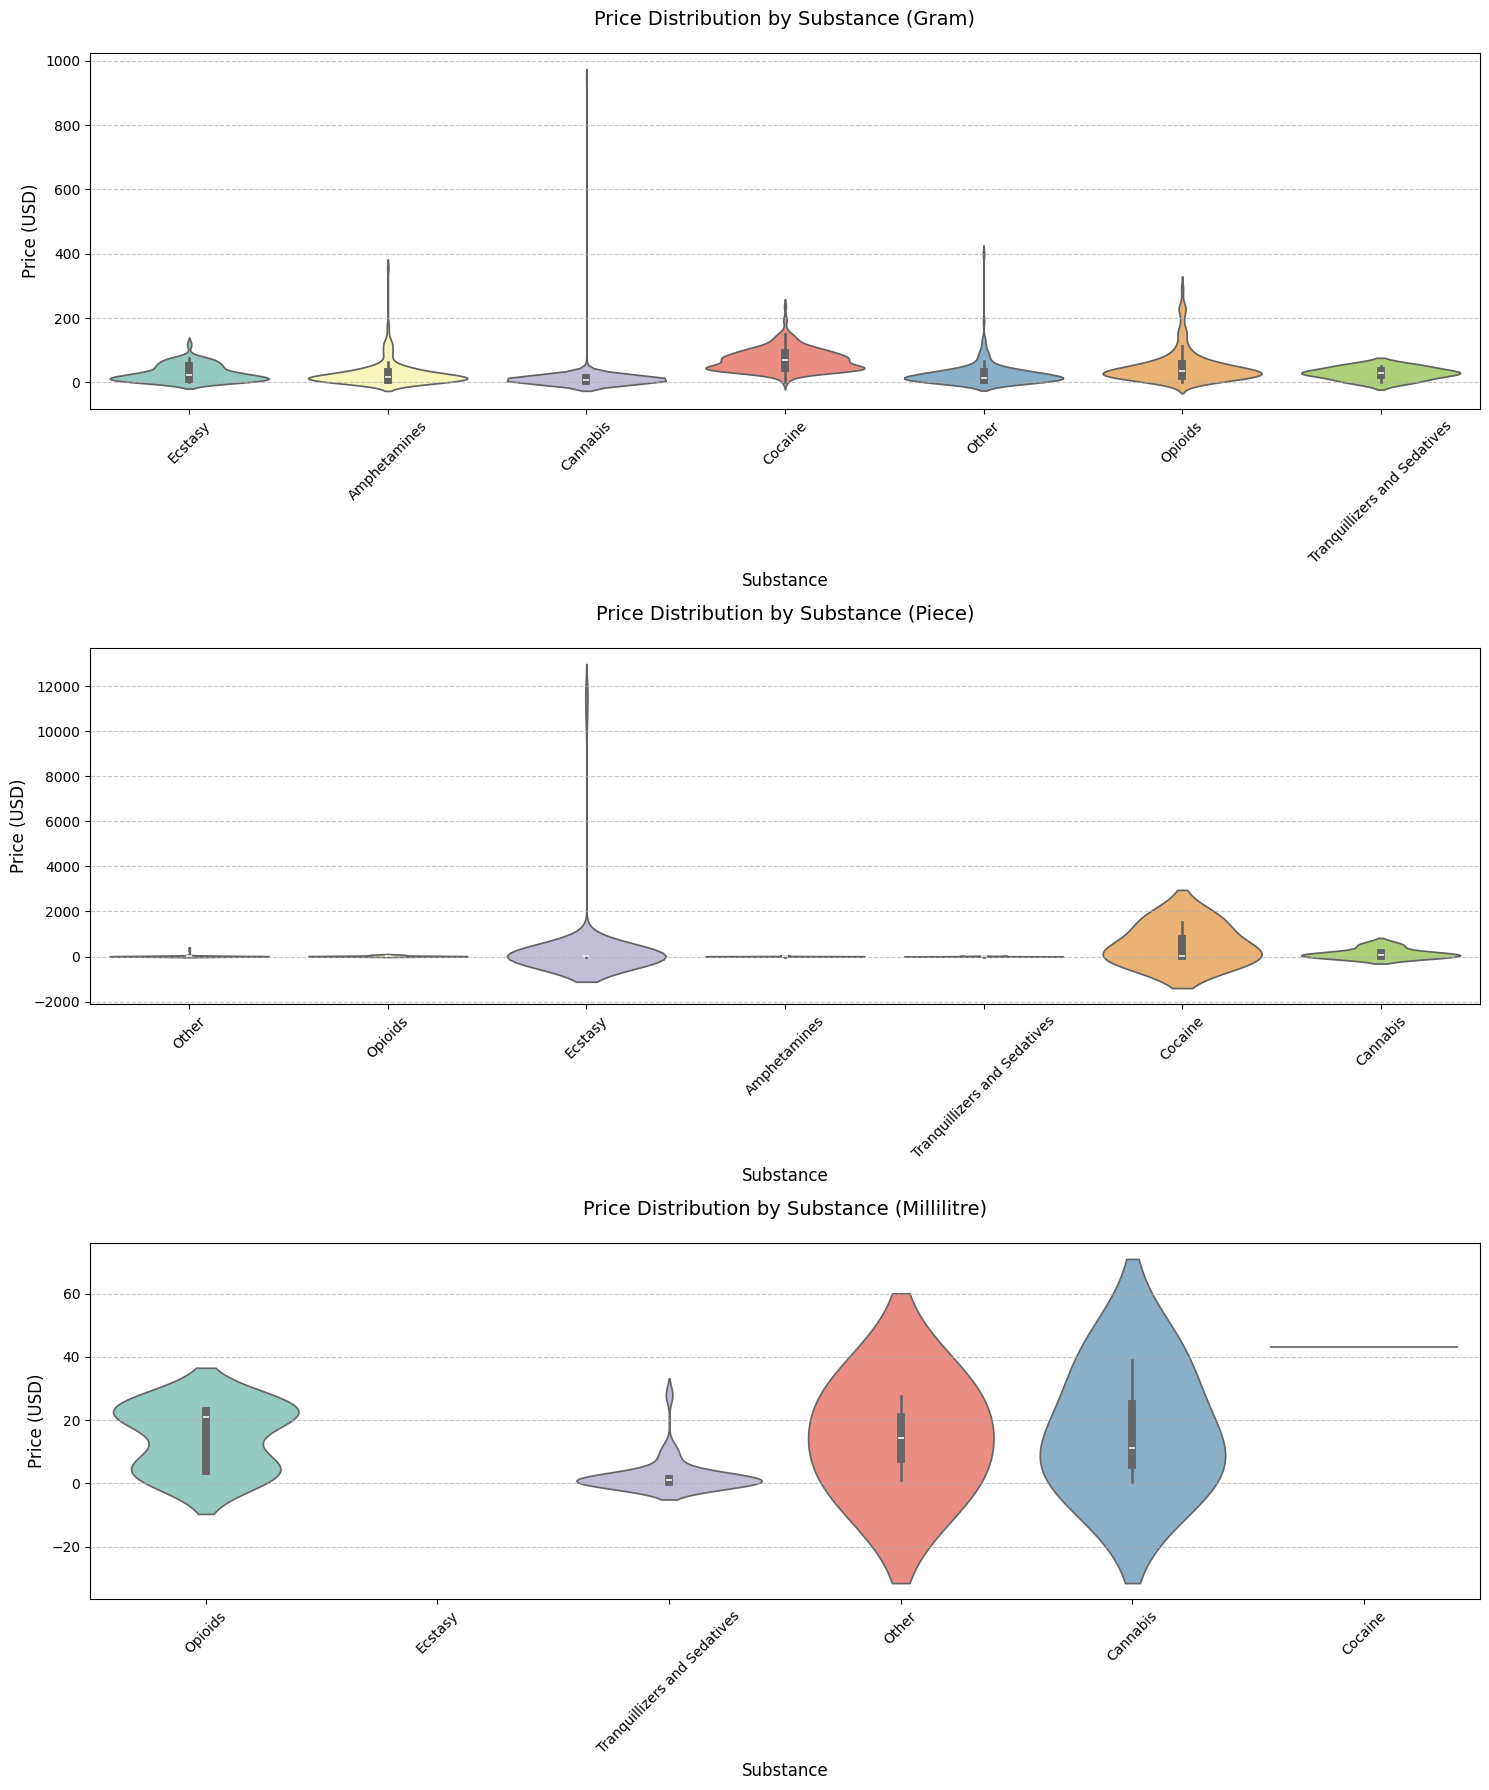

In [156]:
# Get unique units for subplot creation
units = drug_prices_df['Unit'].unique()
n_units = len(units)

# Create figure with subplots
fig, axes = plt.subplots(n_units, 1, figsize=(15, 6*n_units))

# Create a violin plot for each unit
for i, unit in enumerate(units):
    # Filter data for current unit
    unit_data = drug_prices_df[drug_prices_df['Unit'] == unit]
    
    # Create violin plot
    sns.violinplot(data=unit_data, 
                   x='Substance', 
                   y='Typical_USD',
                   hue='Substance',
                   legend=False,
                   ax=axes[i], 
                   palette='Set3',
                   inner='box')  # Shows box plot inside violin
    
    # Customize each subplot
    axes[i].set_title(f'Price Distribution by Substance ({unit})', fontsize=14, pad=20)
    axes[i].set_xlabel('Substance', fontsize=12)
    axes[i].set_ylabel('Price (USD)', fontsize=12)
    
    # Fix the rotation of x-axis labels
    plt.setp(axes[i].get_xticklabels(), rotation=45)
    
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

The image shows three violin plots depicting price distributions for various substances across different units of measurement: grams, piles, and milliliters. In the gram plot, most substances have relatively narrow price ranges, with some showing slight skewness. The piles plot reveals a wider price distribution for certain substances, particularly noticeable for one substance which shows a broad range of prices. The milliliter plot displays more variation in price distributions, with some substances having wider ranges and more complex distributions than others.

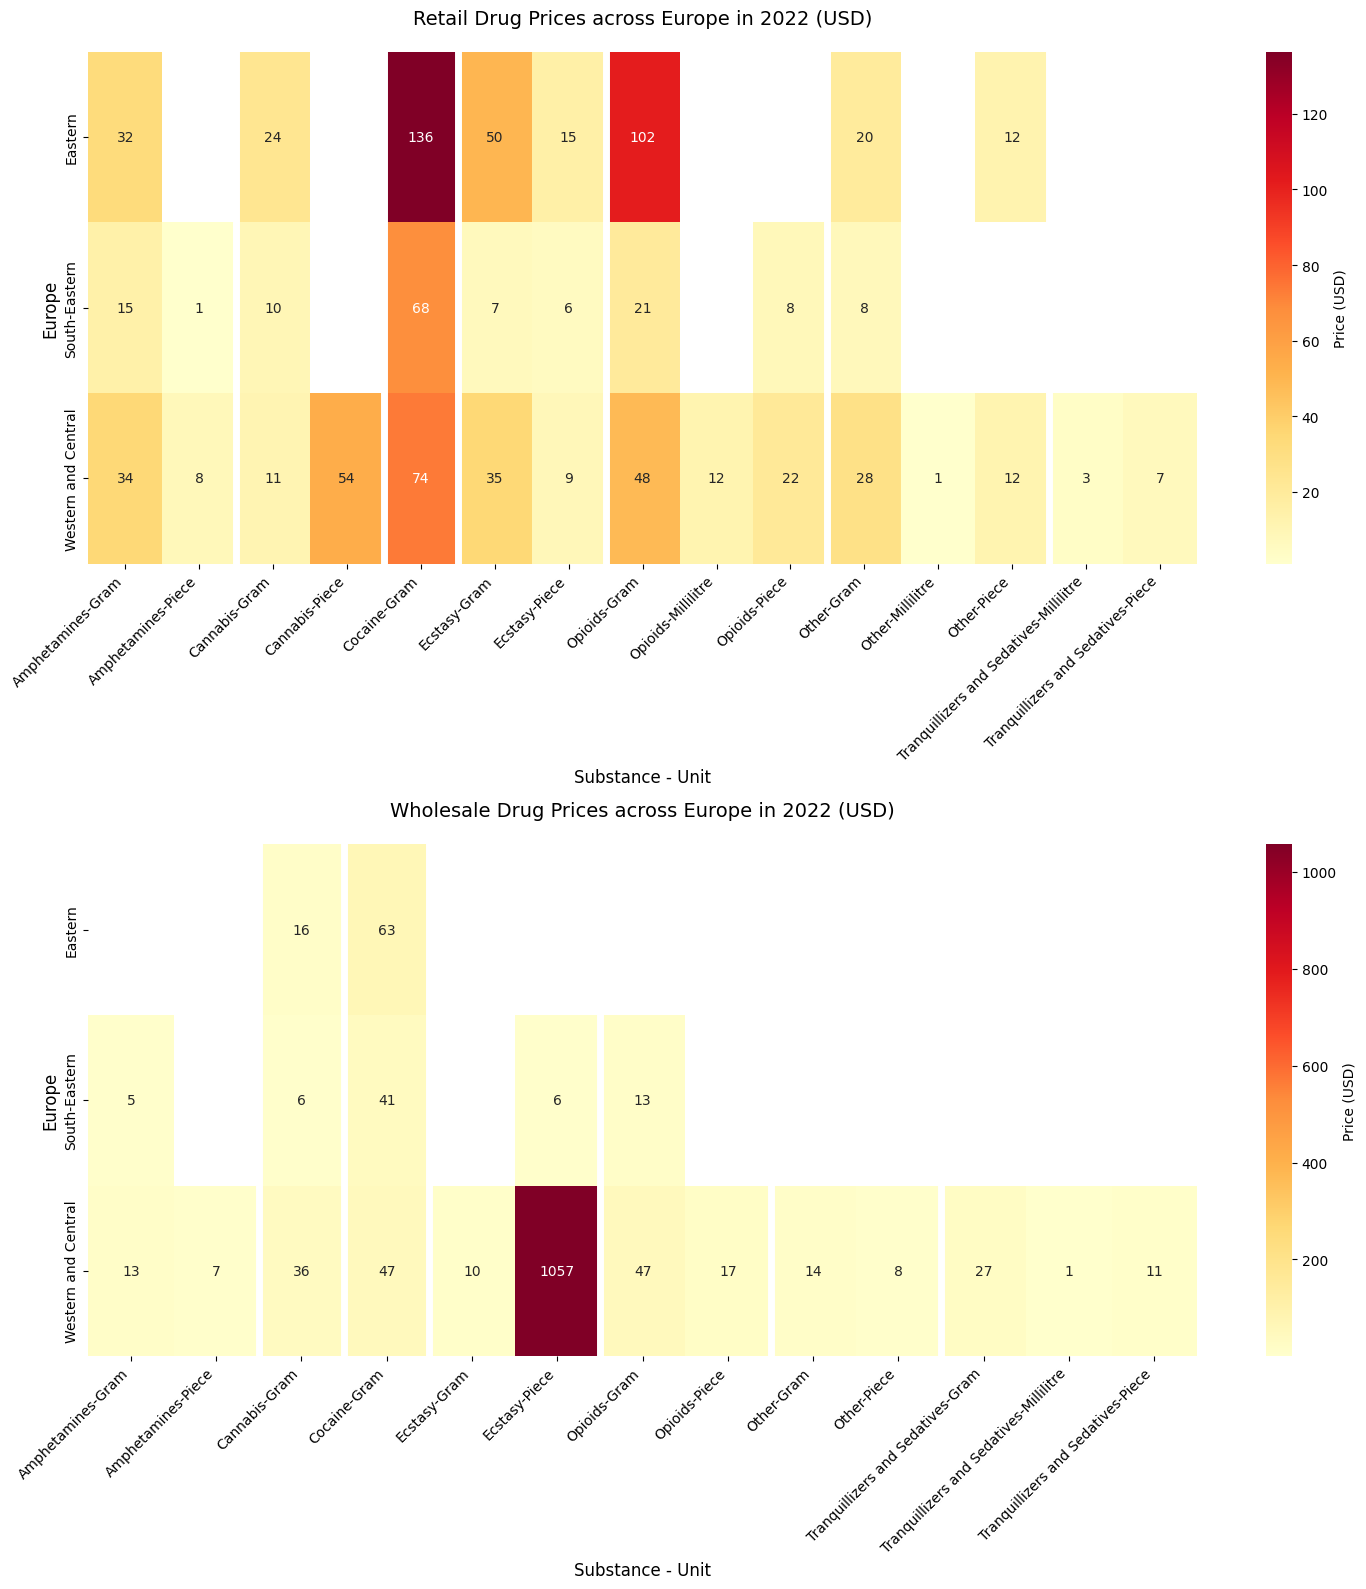

In [157]:
plot_df = drug_prices_df.copy()

latest_year = plot_df['Year'].max()
latest_data = plot_df[plot_df['Year'] == latest_year]

latest_data = plot_df[plot_df['Year'] == latest_year].copy()

latest_data['SubRegion'] = latest_data['SubRegion'].str.replace(' Europe', '')

retail_data = latest_data[latest_data['LevelOfSale'] == 'Retail'].pivot_table(
    values='Typical_USD',
    index='SubRegion',
    columns=['Substance', 'Unit'],
    aggfunc='mean'
)

wholesale_data = latest_data[latest_data['LevelOfSale'] == 'Wholesale'].pivot_table(
    values='Typical_USD',
    index='SubRegion',
    columns=['Substance', 'Unit'],
    aggfunc='mean'
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))

def create_heatmap(data, ax, title):
    sns.heatmap(data, annot=True, fmt='.0f', cmap='YlOrRd', 
                cbar_kws={'label': 'Price (USD)'}, ax=ax)
    
    substances = data.columns.get_level_values('Substance').unique()
    separators = np.cumsum([len(data.columns.get_level_values('Unit')[
        data.columns.get_level_values('Substance') == substance
    ]) for substance in substances])[:-1]
    
    for separator in separators:
        ax.axvline(x=separator, color='white', lw=5)
    
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('Substance - Unit', fontsize=12)
    ax.set_ylabel('Europe', fontsize=12)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

create_heatmap(retail_data, ax1, f'Retail Drug Prices across Europe in {latest_year} (USD)')
create_heatmap(wholesale_data, ax2, f'Wholesale Drug Prices across Europe in {latest_year} (USD)')

plt.tight_layout()
plt.show()

The image shows retail and wholesale drug prices across Europe in 2022 for various substances. In the retail market, cocaine stands out with the highest price at 106 USD, followed by heroin at 56 USD. Most other substances, including cannabis, MDMA, and amphetamine, have retail prices ranging from 10 to 25 USD.

In the wholesale market, cocaine again has the highest price at 55,957 USD, which is dramatically higher than all other substances. Heroin is the second most expensive at 24 USD wholesale. The majority of other drugs have wholesale prices under 10 USD, with cannabis resin at 5 USD and amphetamine at 4 USD being among the lowest.

The stark difference between cocaine's retail and wholesale prices, as well as its significant price gap compared to other substances, suggests unique market dynamics or regulatory factors affecting its distribution and sale in Europe.

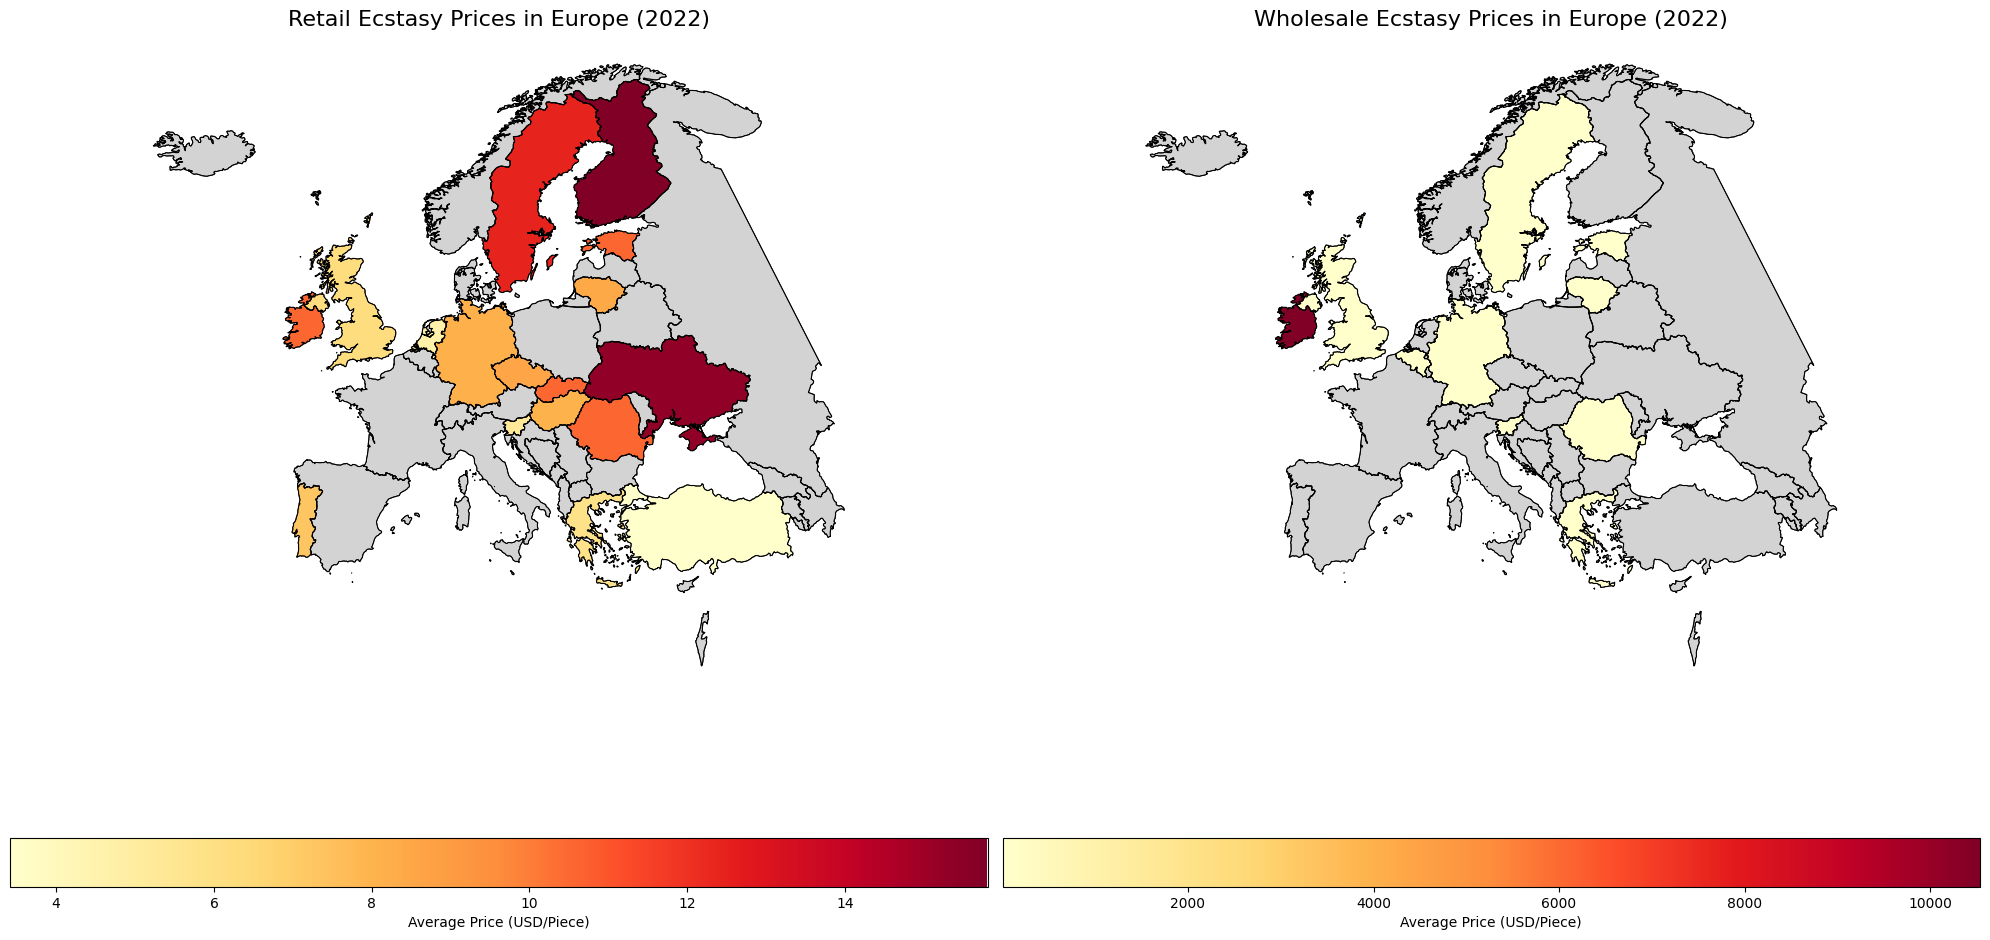

In [158]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

# Load the GeoJSON file
url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)
drug = 'Ecstasy'
unit = 'Piece'
year = 2022
plot_df = drug_prices_df.copy()
# Filter data for the year 2022
df_filtered = plot_df[(plot_df['Year'] == year) & (
    plot_df['Substance'] == drug) & (plot_df['Unit'] == unit)]

# Prepare data for Retail and Wholesale
retail_data = df_filtered[df_filtered['LevelOfSale'] == 'Retail'].groupby(
    'Country')['Typical_USD'].mean().reset_index()
wholesale_data = df_filtered[df_filtered['LevelOfSale'] == 'Wholesale'].groupby(
    'Country')['Typical_USD'].mean().reset_index()

# Merge GeoDataFrame with the price data
europe_retail = europe_gdf.merge(
    retail_data, how='left', left_on='NAME', right_on='Country')
europe_wholesale = europe_gdf.merge(
    wholesale_data, how='left', left_on='NAME', right_on='Country')

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Function to plot map


def plot_map(gdf, ax, title):
    gdf.plot(column='Typical_USD', ax=ax, legend=True,
             legend_kwds={
                 'label': f'Average Price (USD/{unit})', 'orientation': 'horizontal'},
             missing_kwds={'color': 'lightgrey'}, cmap='YlOrRd',
             edgecolor='black', linewidth=0.5)
    gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
    ax.axis('off')
    ax.set_title(title, fontsize=16)


# Plot Retail map
plot_map(europe_retail, ax1, f'Retail {drug} Prices in Europe ({year})')

# Plot Wholesale map
plot_map(europe_wholesale, ax2, f'Wholesale {drug} Prices in Europe ({year})')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

This image presents two maps of Europe comparing retail and wholesale ecstasy prices in 2022.

The retail map (left) shows significant price variations across countries. Northern and Eastern European countries, particularly Sweden, Finland, and some Baltic states, display the highest retail prices, indicated by dark red. Western and Central European countries show moderate prices (orange to light red), while Southern European countries generally have lower prices (yellow to light orange).

The wholesale map (right) reveals a different pattern. Most countries have relatively low wholesale prices (pale yellow), suggesting more uniform costs at the distribution level. Only a few countries, notably Sweden and Finland, show slightly higher wholesale prices (darker yellow).

The stark contrast between retail and wholesale prices, especially in Northern Europe, suggests substantial markup in these regions, possibly due to factors like stricter regulations, higher risks, or increased demand. The more uniform wholesale prices across Europe imply that price differences at the retail level are largely influenced by local market conditions and policies rather than supply-side costs.

## Calculate the Spread

In [159]:
drug_prices_df['Spread_USD'] = drug_prices_df['Maximum_USD'] - drug_prices_df['Minimum_USD']
drug_prices_df['Spread_rel'] = drug_prices_df['Spread_USD'] / drug_prices_df['Typical_USD']

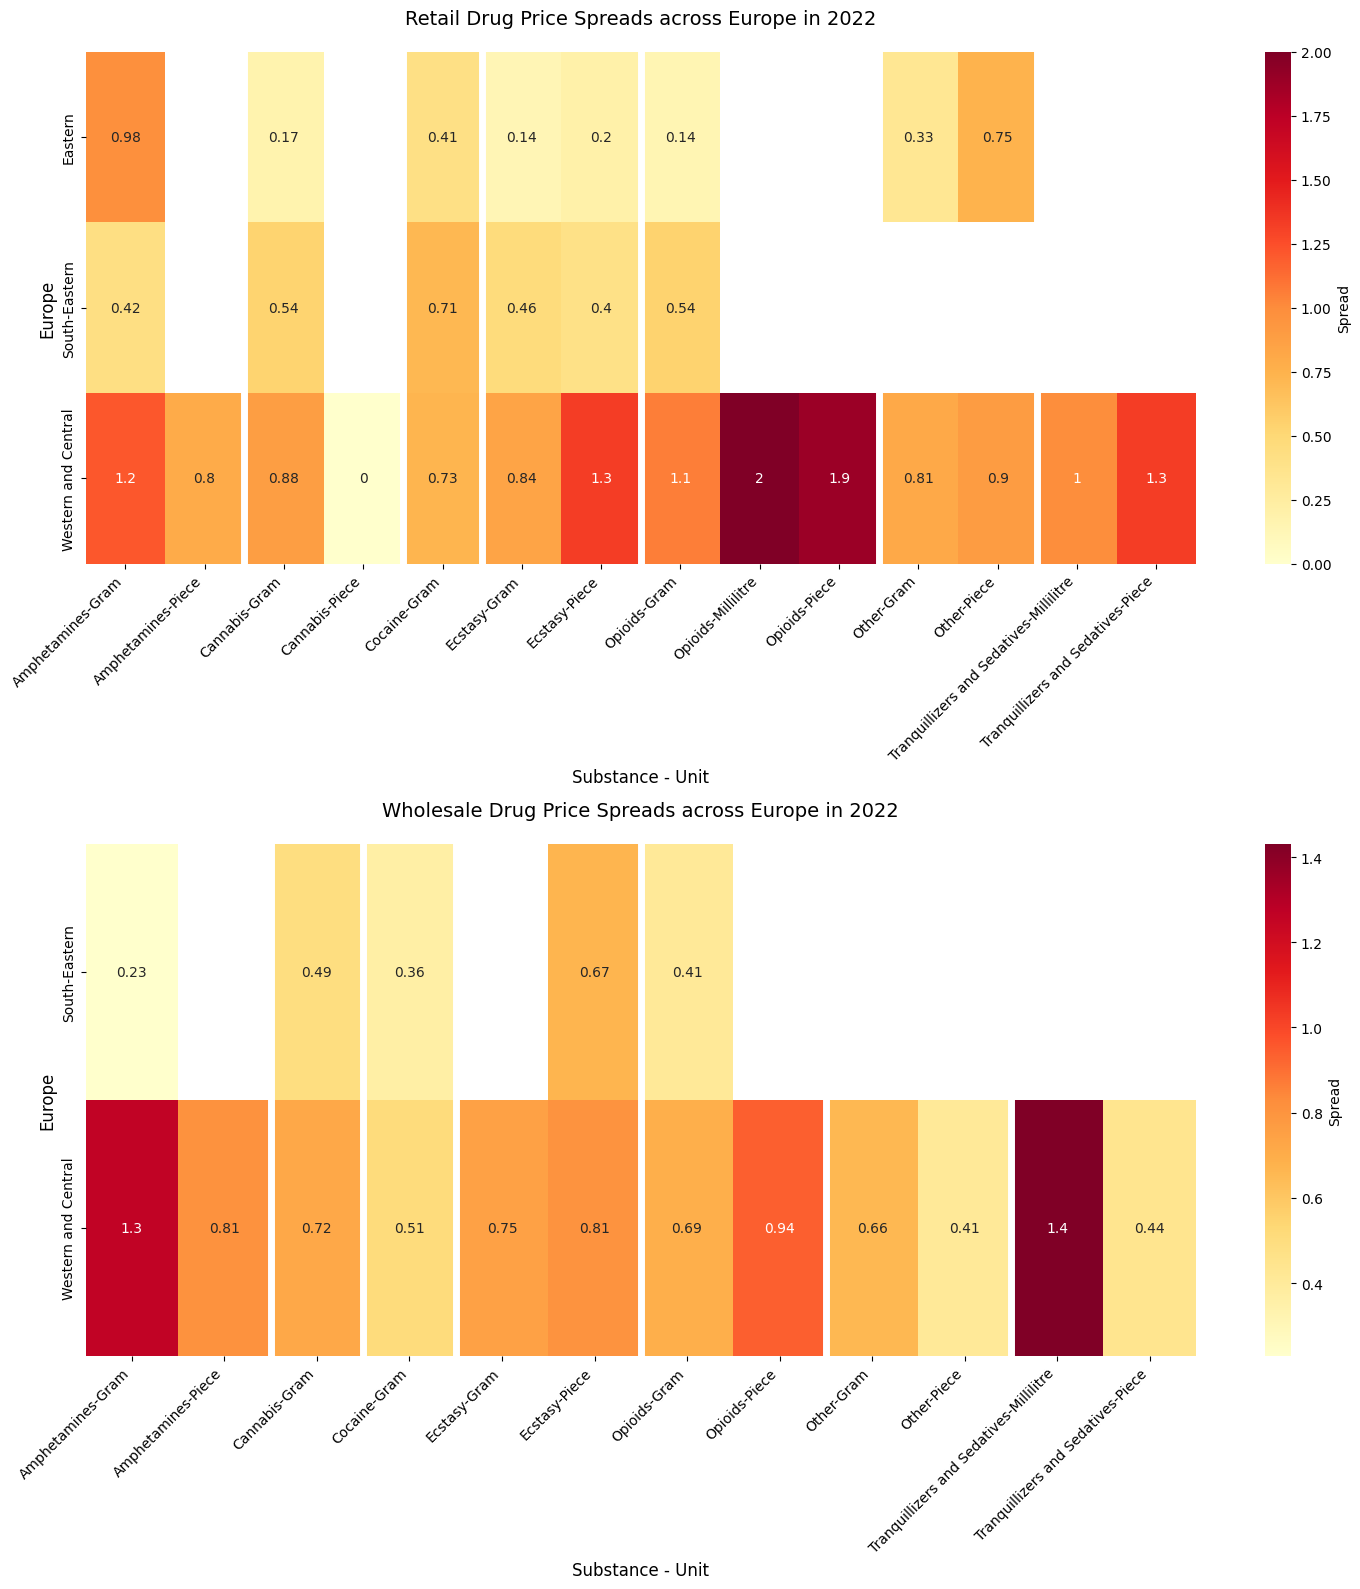

In [160]:
plot_df = drug_prices_df.copy()

latest_year = plot_df['Year'].max()
latest_data = plot_df[plot_df['Year'] == latest_year]

latest_data = plot_df[plot_df['Year'] == latest_year].copy()

latest_data['SubRegion'] = latest_data['SubRegion'].str.replace(' Europe', '')

retail_data = latest_data[latest_data['LevelOfSale'] == 'Retail'].pivot_table(
    values='Spread_rel',
    index='SubRegion',
    columns=['Substance', 'Unit'],
    aggfunc='mean'
)

wholesale_data = latest_data[latest_data['LevelOfSale'] == 'Wholesale'].pivot_table(
    values='Spread_rel',
    index='SubRegion',
    columns=['Substance', 'Unit'],
    aggfunc='mean'
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))

def create_heatmap(data, ax, title):
    sns.heatmap(data, annot=True,  cmap='YlOrRd', 
                cbar_kws={'label': 'Spread'}, ax=ax)
    
    substances = data.columns.get_level_values('Substance').unique()
    separators = np.cumsum([len(data.columns.get_level_values('Unit')[
        data.columns.get_level_values('Substance') == substance
    ]) for substance in substances])[:-1]
    
    for separator in separators:
        ax.axvline(x=separator, color='white', lw=5)
    
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('Substance - Unit', fontsize=12)
    ax.set_ylabel('Europe', fontsize=12)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

create_heatmap(retail_data, ax1, f'Retail Drug Price Spreads across Europe in {latest_year}')
create_heatmap(wholesale_data, ax2, f'Wholesale Drug Price Spreads across Europe in {latest_year}')

plt.tight_layout()
plt.show()

### Interpreting the Relative Spread:

- A higher relative spread indicates greater price variability relative to the typical price.
- A relative spread of 1 means the difference between the maximum and minimum is equal to the typical price.
- In the data, some drugs have a relative spread greater than 1, indicating high variability.

This image displays two heat maps comparing retail and wholesale drug price spreads across Europe in 2022.

In the retail market (top chart) cocaine shows the highest price spread at 1.71 indicating significant variability in its retail pricing across Europe. Other substances with notable retail price spreads include methamphetamine (0.75), heroin (0.67), and amphetamine (0.66). Cannabis products (herb and resin) show relatively lower spreads, suggesting more consistent retail pricing across the region.

The wholesale market (bottom chart) presents a different picture. Here, methamphetamine has the highest price spread at 1.4, followed closely by cocaine at 1.3. Interestingly, MDMA powder shows a higher spread in the wholesale market (0.97) compared to its retail spread (0.34), suggesting more variability in bulk pricing than in street-level sales.

Overall the data indicates that price variability is generally higher in the retail market than in the wholesale market for most substances. This could reflect differences in local demand, enforcement efforts, and distribution networks across European countries. The significant spreads for cocaine and methamphetamine in both markets suggest these substances face the most variable market conditions across Europe.

## Calculate the Inland Margin
calculate the margin if drugs are bought wholesale and sold retail in the same country

In [161]:
retail_df = drug_prices_df[drug_prices_df['LevelOfSale'] == 'Retail']
wholesale_df = drug_prices_df[drug_prices_df['LevelOfSale'] == 'Wholesale']

retail_prices = retail_df.groupby(['Country', 'Substance'])['Typical_USD'].mean().reset_index()
wholesale_prices = wholesale_df.groupby(['Country', 'Substance'])['Typical_USD'].mean().reset_index()

inland_margin = pd.merge(retail_prices, wholesale_prices, on=['Country', 'Substance'], how='inner', suffixes=('_Retail', '_Wholesale'))

inland_margin['Margin'] = inland_margin['Typical_USD_Retail'] - inland_margin['Typical_USD_Wholesale']
inland_margin['RelativeMargin'] = (inland_margin['Margin'] / inland_margin['Typical_USD_Wholesale']) * 100
inland_margin = inland_margin.dropna(subset='RelativeMargin')

inland_best_margin = inland_margin.loc[inland_margin.groupby('Country')['RelativeMargin'].idxmax()].reset_index(drop=True)
columns_to_display = ['Country', 'Substance', 'Typical_USD_Retail', 'Typical_USD_Wholesale', 'Margin', 'RelativeMargin']

display(inland_best_margin[columns_to_display])

,Country,Substance,Typical_USD_Retail,Typical_USD_Wholesale,Margin,RelativeMargin
0,Albania,Cocaine,94.451004,39.193729,55.257275,140.984989
1,Austria,Ecstasy,20.594966,7.151030,13.443936,188.000000
2,Belarus,Opioids,120.000000,22.834885,97.165115,425.511741
3,Belgium,Tranquillizers and Sedatives,19.330275,0.233609,19.096666,8174.619658
4,Bosnia and Herzegovina,Opioids,26.516955,17.793594,8.723361,49.025290
5,Bulgaria,Ecstasy,6.309024,1.092233,5.216791,477.626211
6,Croatia,Amphetamines,13.982426,2.417269,11.565158,478.439079
7,Czech Republic,Ecstasy,8.920319,3.083427,5.836892,189.298887
8,Denmark,Other,19.386280,3.084737,16.301542,528.458041
9,Estonia,Amphetamines,22.772572,4.812781,17.959791,373.168645


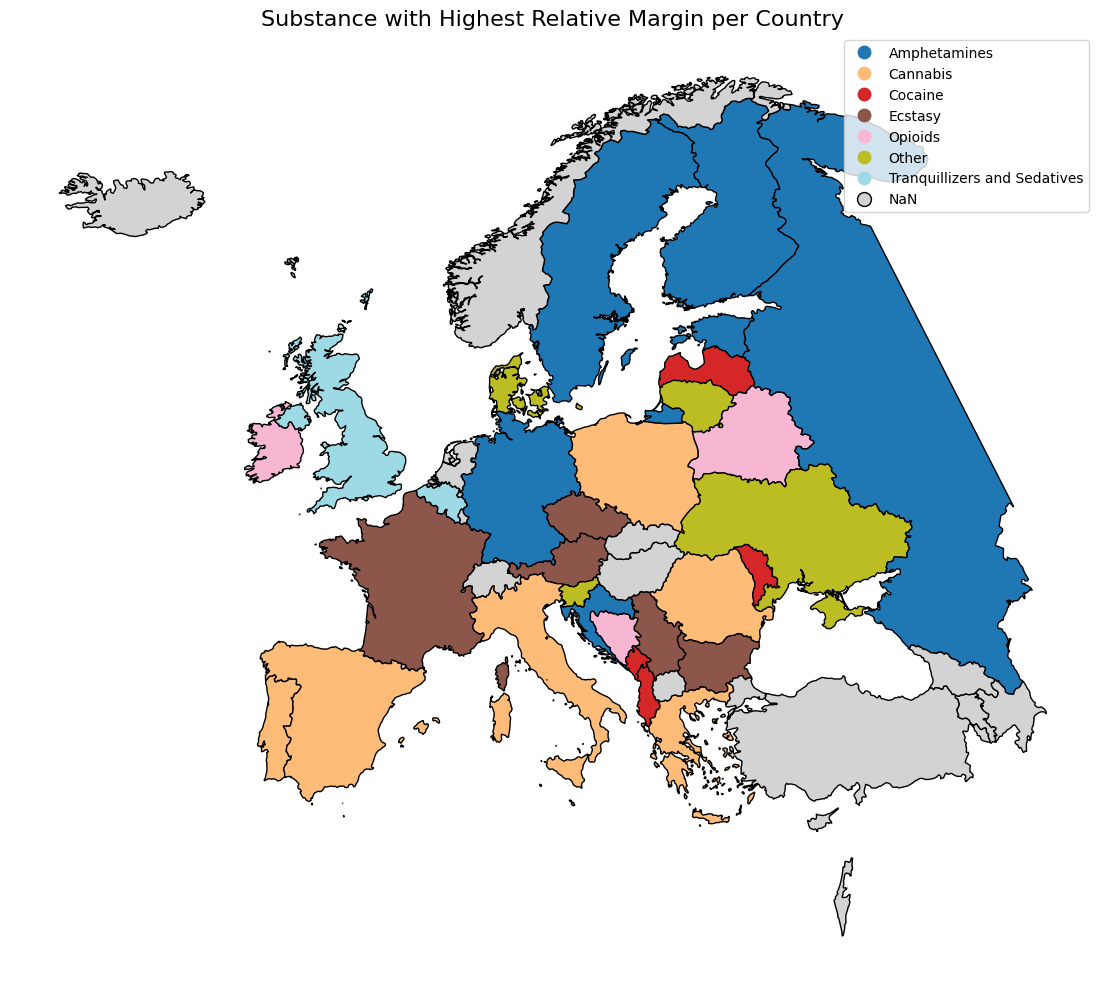

In [162]:
import matplotlib.patches as mpatches

url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)

map_df = europe_gdf.merge(inland_best_margin, how='left',
                          left_on='NAME', right_on='Country')

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

map_df.plot(column='Substance', ax=ax, legend=True, cmap='tab20',
            missing_kwds={'color': 'lightgrey'}, edgecolor='black')

ax.axis('off')
ax.set_title('Substance with Highest Relative Margin per Country', fontsize=16)

plt.tight_layout()
plt.show()

## Purity

In [163]:
drug_purity_df.head()

,Region,SubRegion,Country,LevelOfSale,DrugGroup,Drug,Specify,Year,Typical,Minimum,Maximum,Measurement,Substance
0,Europe,Eastern Europe,Belarus,Retail,Opioids,Heroin,NaN,2022,97.0,95.0,98.0,% (percent),Opioids
1,Europe,Eastern Europe,Belarus,Retail,Opioids,Methadone,NaN,2022,97.0,95.0,98.0,% (percent),Opioids
2,Europe,Eastern Europe,Belarus,Retail,“Ecstasy”-type substances,MDMA,NaN,2021,97.0,95.0,98.0,% (percent),Ecstasy
3,Europe,Eastern Europe,Belarus,Retail,Amphetamine-type stimulants,Amphetamine powder,NaN,2021,97.0,95.0,98.0,% (percent),Amphetamines
4,Europe,Eastern Europe,Belarus,Retail,Amphetamine-type stimulants,Methamphetamine powder,NaN,2021,97.0,95.0,98.0,% (percent),Amphetamines


In [164]:
drug_purity_df['Measurement'].unique()

array(['% (percent)', 'mg/tablet', '...', nan], dtype=object)

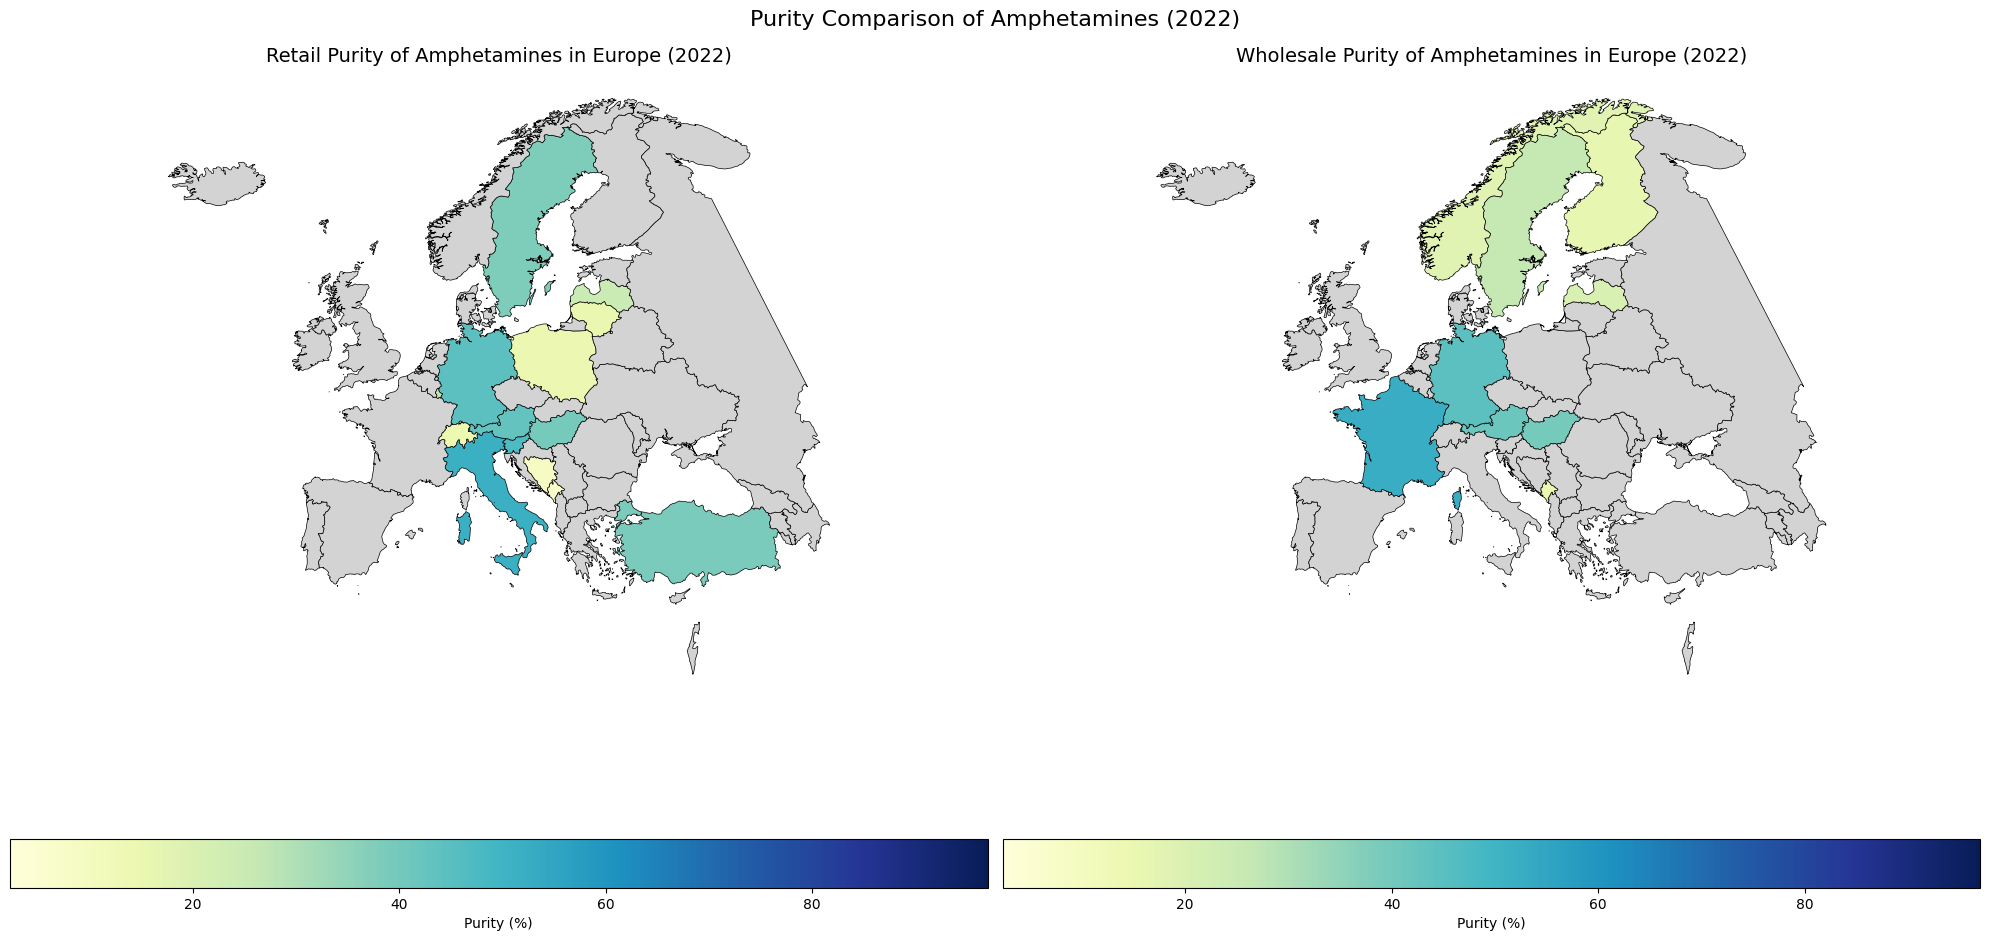

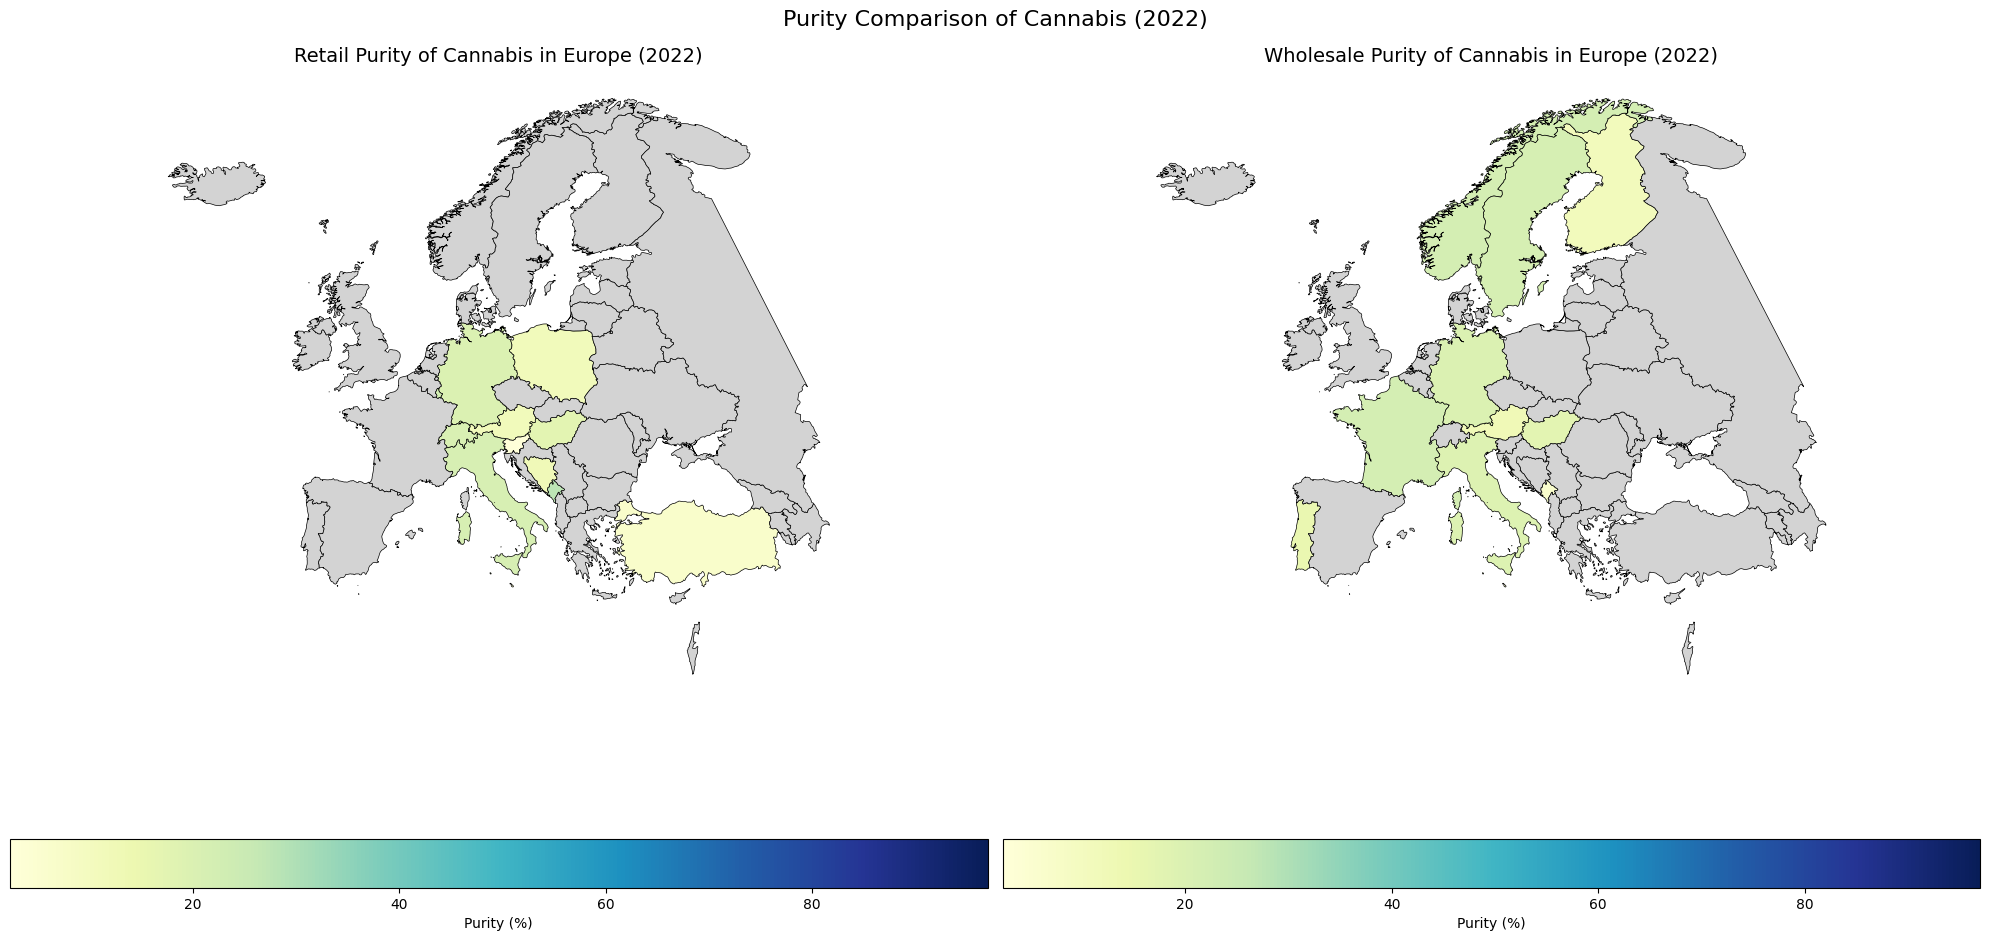

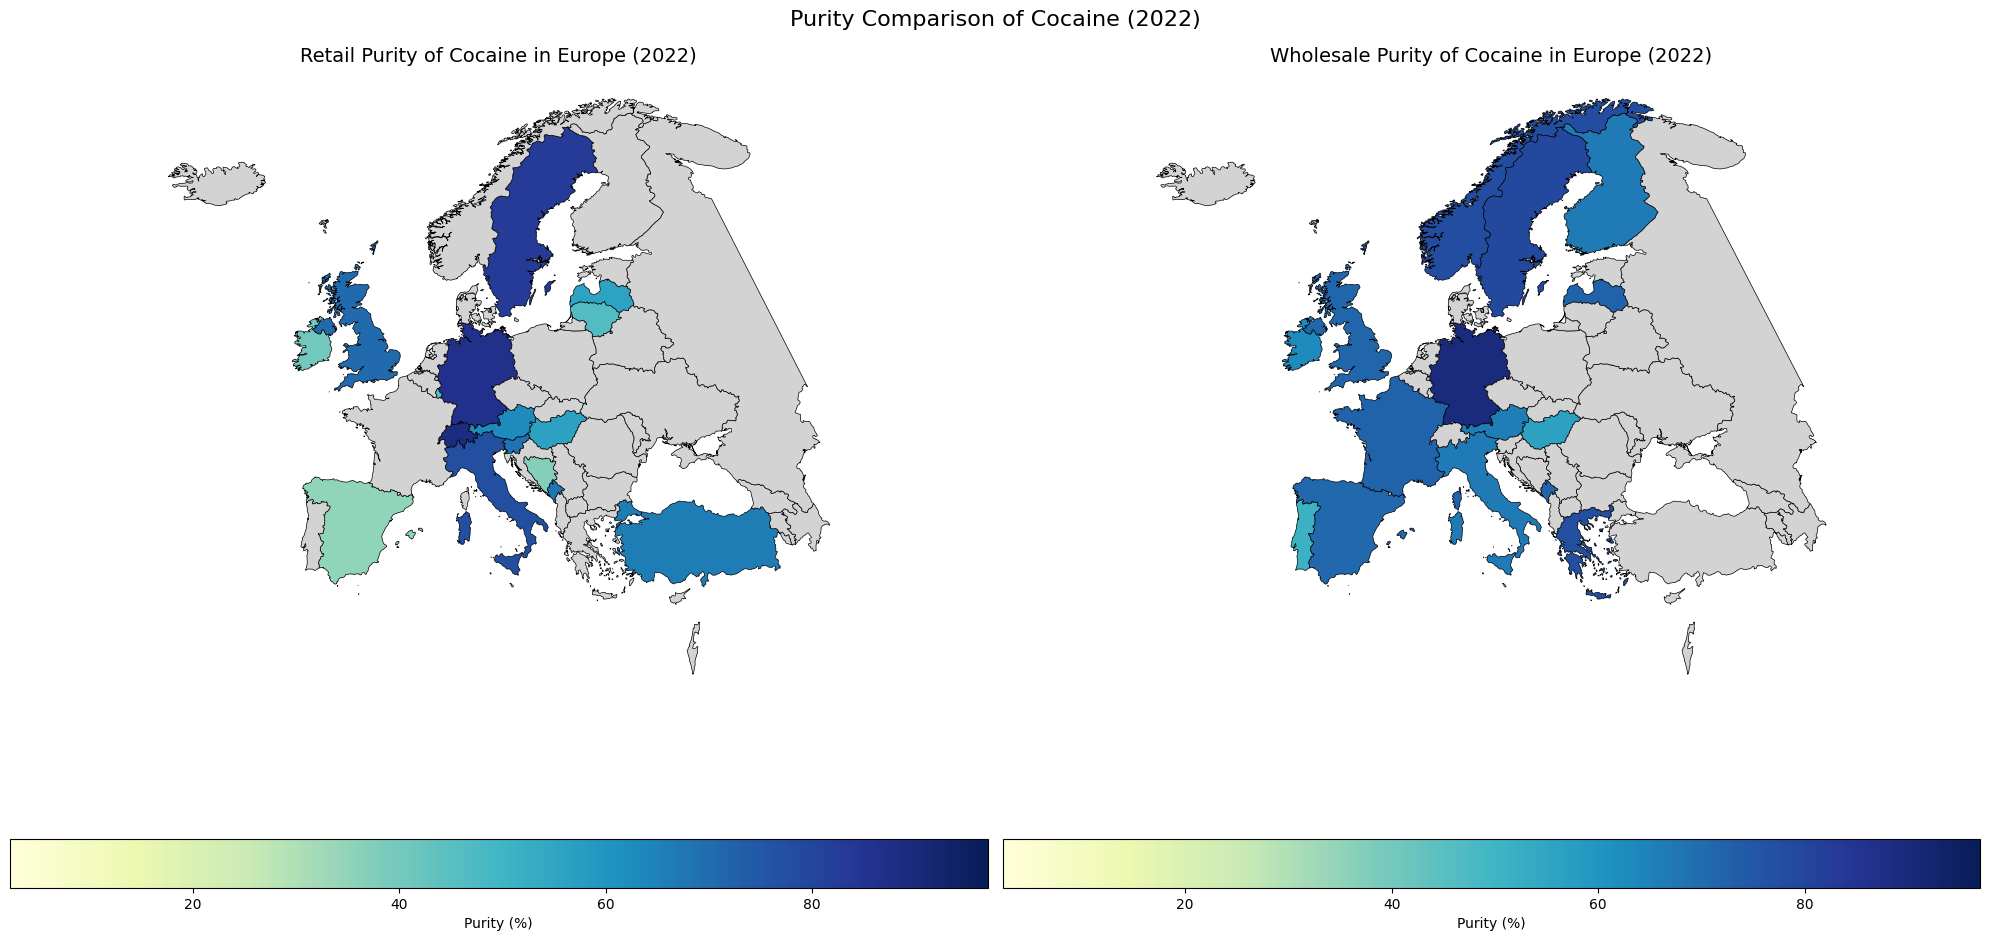

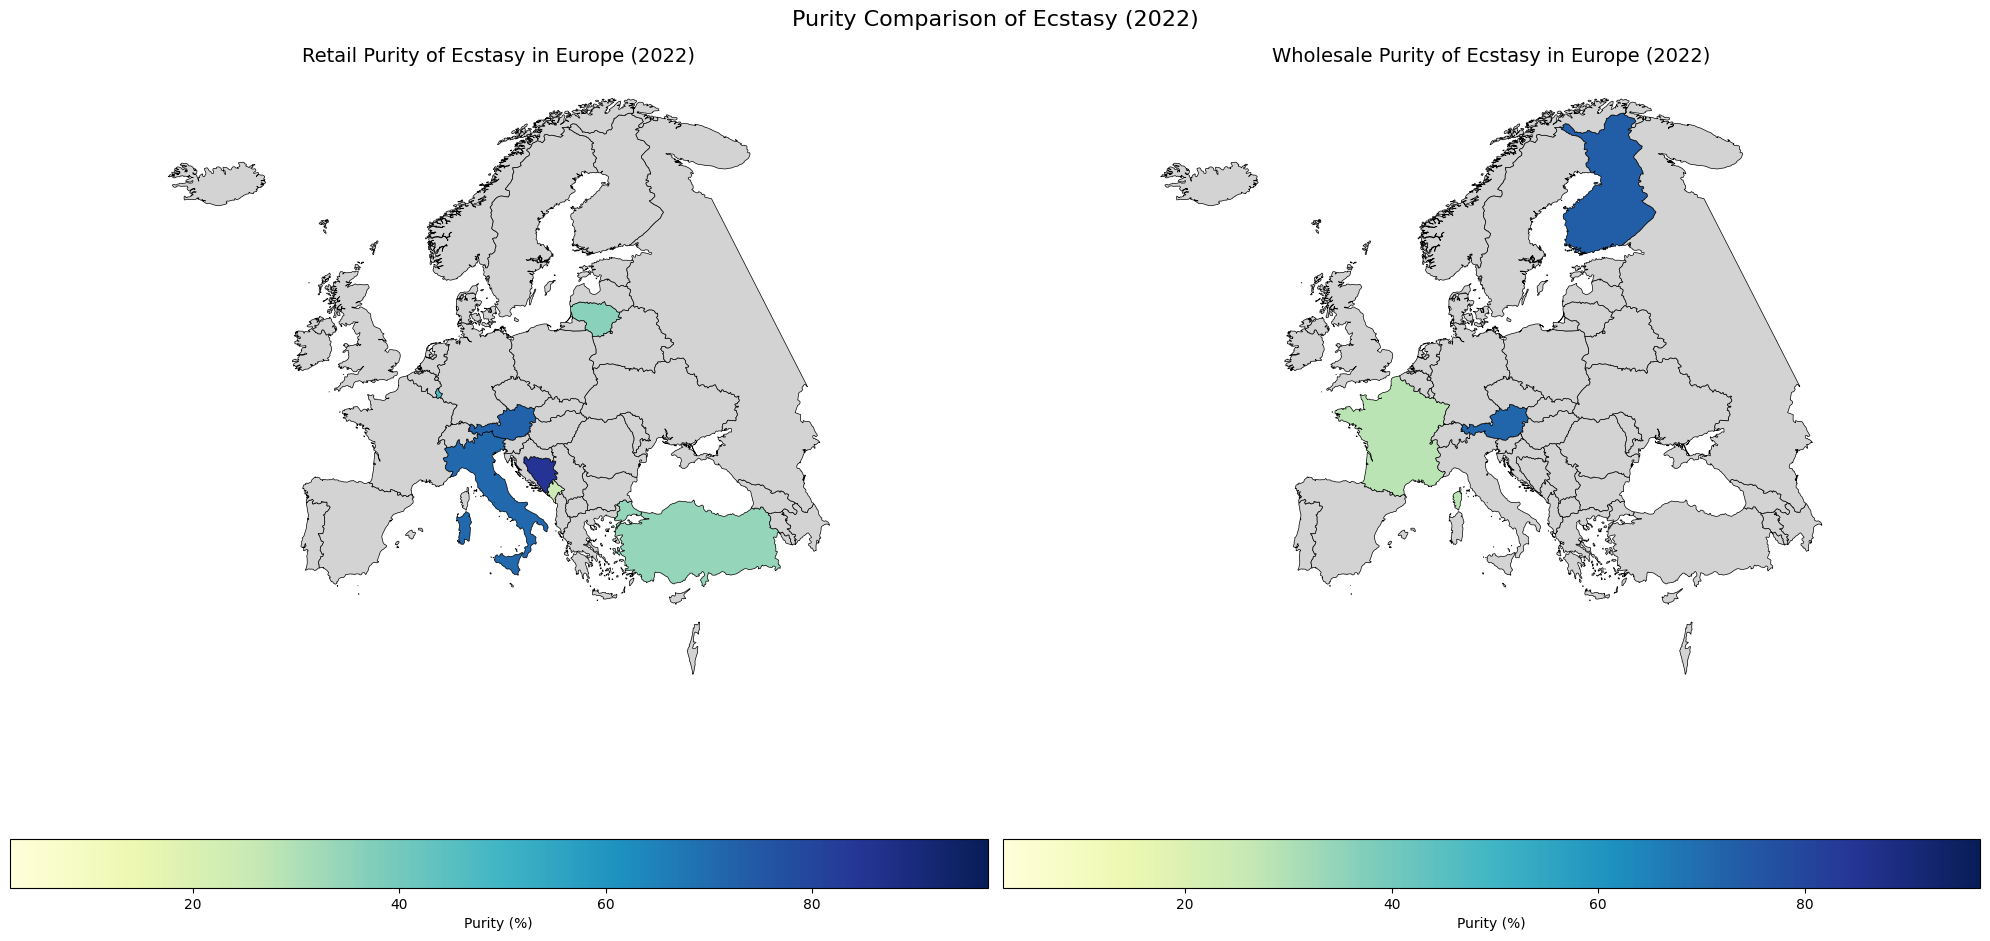

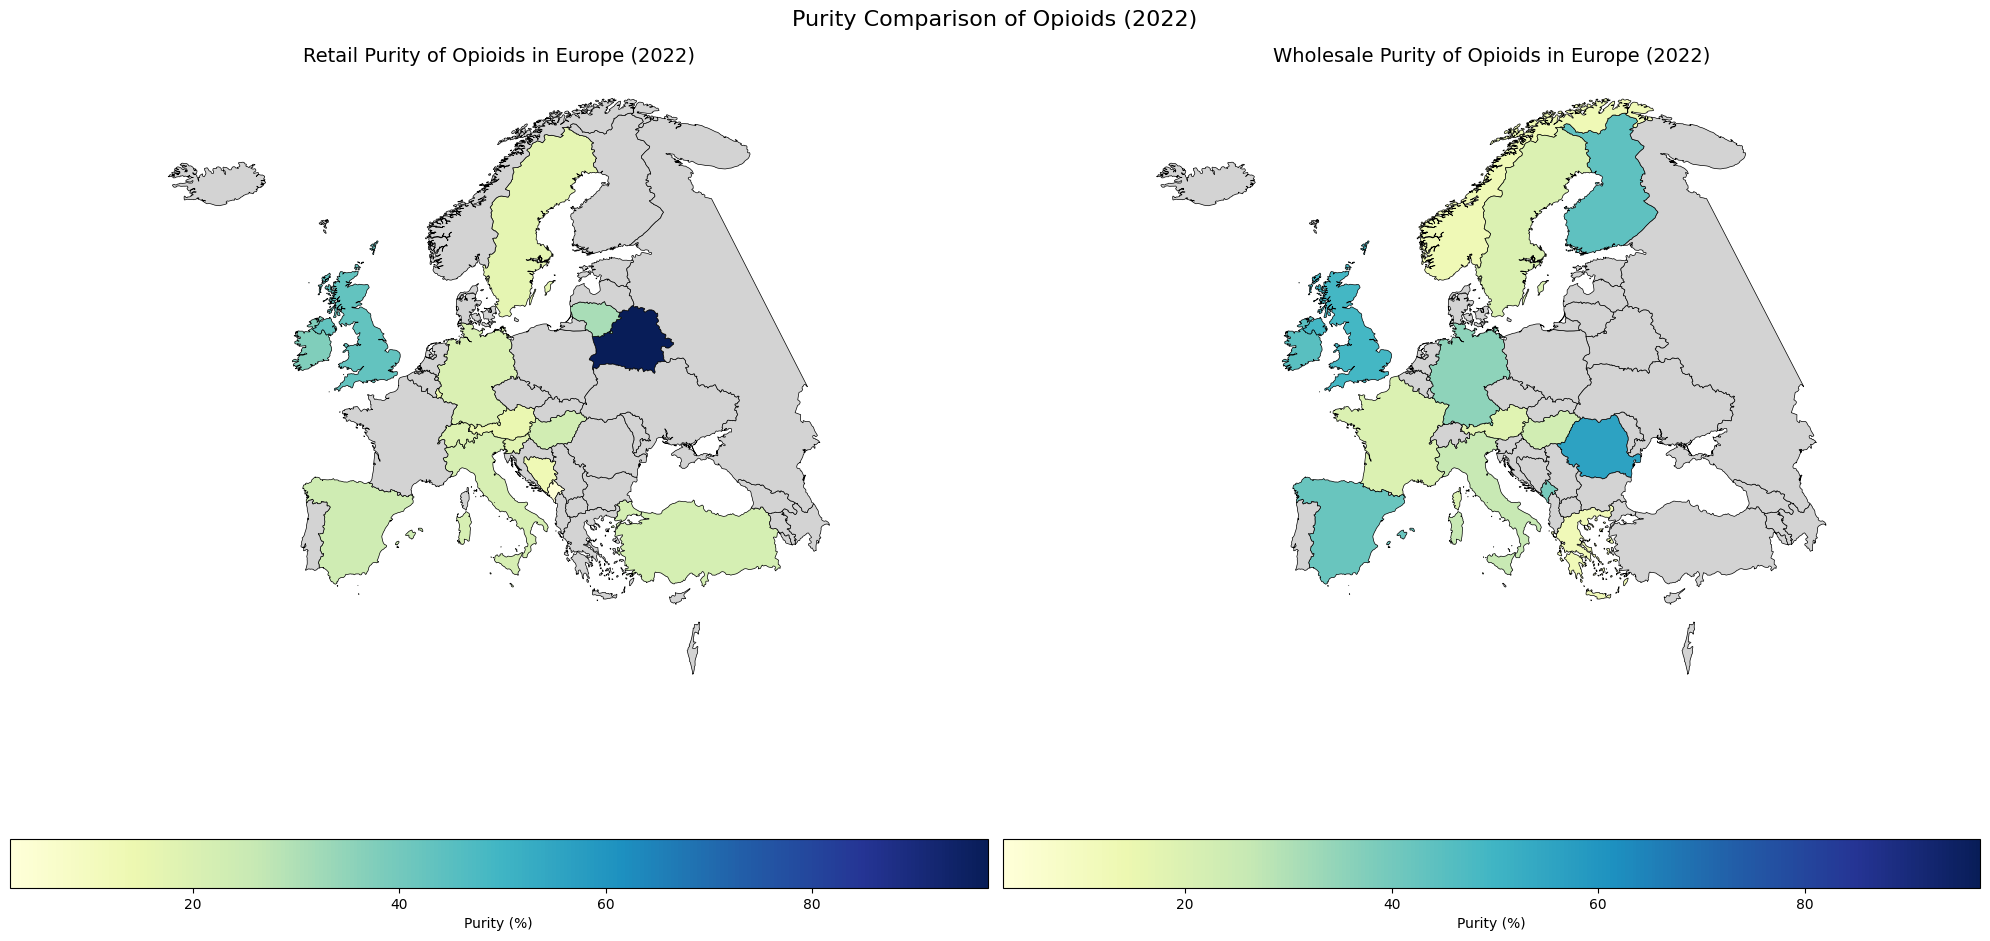

In [165]:
df_filtered = drug_purity_df[(drug_purity_df['Year'] == 2022)&(drug_purity_df['Measurement']=='% (percent)')]
purity_df = df_filtered.groupby(['Substance', 'LevelOfSale', 'Country'])['Typical'].mean().reset_index()


url = "https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson"
response = requests.get(url)
europe_gdf = gpd.read_file(response.content)

substances = purity_df['Substance'].unique()

for substance in substances:
    substance_df = purity_df[purity_df['Substance'] == substance]

    retail_data = substance_df[substance_df['LevelOfSale'] == 'Retail']
    wholesale_data = substance_df[substance_df['LevelOfSale'] == 'Wholesale']

    retail_map_df = europe_gdf.merge(retail_data, how='left', left_on='NAME', right_on='Country')
    wholesale_map_df = europe_gdf.merge(wholesale_data, how='left', left_on='NAME', right_on='Country')

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    cmap = 'YlGnBu'

    vmin = min(purity_df['Typical'])
    vmax = max(purity_df['Typical'])

    ax1 = axes[0]
    retail_map_df.plot(column='Typical', ax=ax1, legend=True,
                        legend_kwds={'label': 'Purity (%)', 'orientation': 'horizontal'},
                        cmap=cmap, edgecolor='black', linewidth=0.5,
                        vmin=vmin, vmax=vmax,
                        missing_kwds={'color': 'lightgrey'})
    ax1.set_title(f'Retail Purity of {substance} in Europe (2022)', fontsize=14)
    ax1.axis('off')

    ax2 = axes[1]
    wholesale_map_df.plot(column='Typical', ax=ax2, legend=True,
                            legend_kwds={'label': 'Purity (%)', 'orientation': 'horizontal'},
                            cmap=cmap, edgecolor='black', linewidth=0.5,
                            vmin=vmin, vmax=vmax,
                            missing_kwds={'color': 'lightgrey'})
    ax2.set_title(f'Wholesale Purity of {substance} in Europe (2022)', fontsize=14)
    ax2.axis('off')

    fig.suptitle(f'Purity Comparison of {substance} (2022)', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)

    plt.show()

## Seizures

In [166]:
drug_seizures_df.head()

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Year,Kilograms,msCode,Substance
0,Europe,Eastern Europe,Belarus,“Ecstasy”-type substances,“Ecstasy”-type substances,"3,4-methylenedioxymethamphetamine (MDMA)",2022,1.037000,BLR,Ecstasy
1,Europe,Eastern Europe,Belarus,Amphetamine-type stimulants (excluding “ecstasy”),Amphetamine,Amphetamine,2022,1.758000,BLR,Amphetamines
2,Europe,Eastern Europe,Belarus,Amphetamine-type stimulants (excluding “ecstasy”),Methamphetamine,Methamphetamine,2022,1.248000,BLR,Amphetamines
3,Europe,Eastern Europe,Belarus,Amphetamine-type stimulants (excluding “ecstasy”),Other stimulants,"Mephedrone (4-methylmethcathinone, 4-MMC)",2022,0.054386,BLR,Amphetamines
4,Europe,Eastern Europe,Belarus,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2022,64.008000,BLR,Cannabis


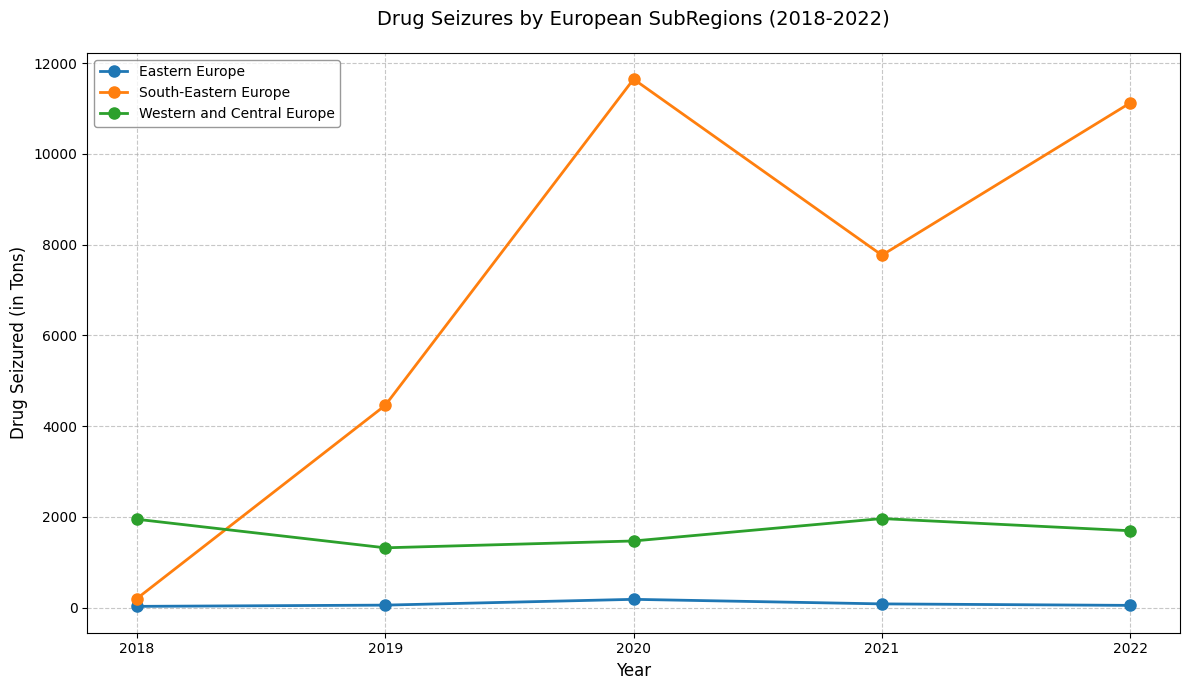

In [167]:
eu_seizures_per_subregion_and_year = drug_seizures_df[['SubRegion','Year','Kilograms']]
df_grouped = eu_seizures_per_subregion_and_year.groupby(['SubRegion', 'Year']).sum().reset_index()

df_grouped['Tons'] = df_grouped['Kilograms'] / 1000

df_pivot = df_grouped.pivot(index='Year', columns='SubRegion', values='Tons')

plt.figure(figsize=(12, 7))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], marker='o', linewidth=2, markersize=8, label=column)

plt.title('Drug Seizures by European SubRegions (2018-2022)', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Drug Seizured (in Tons)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1))
plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.show()

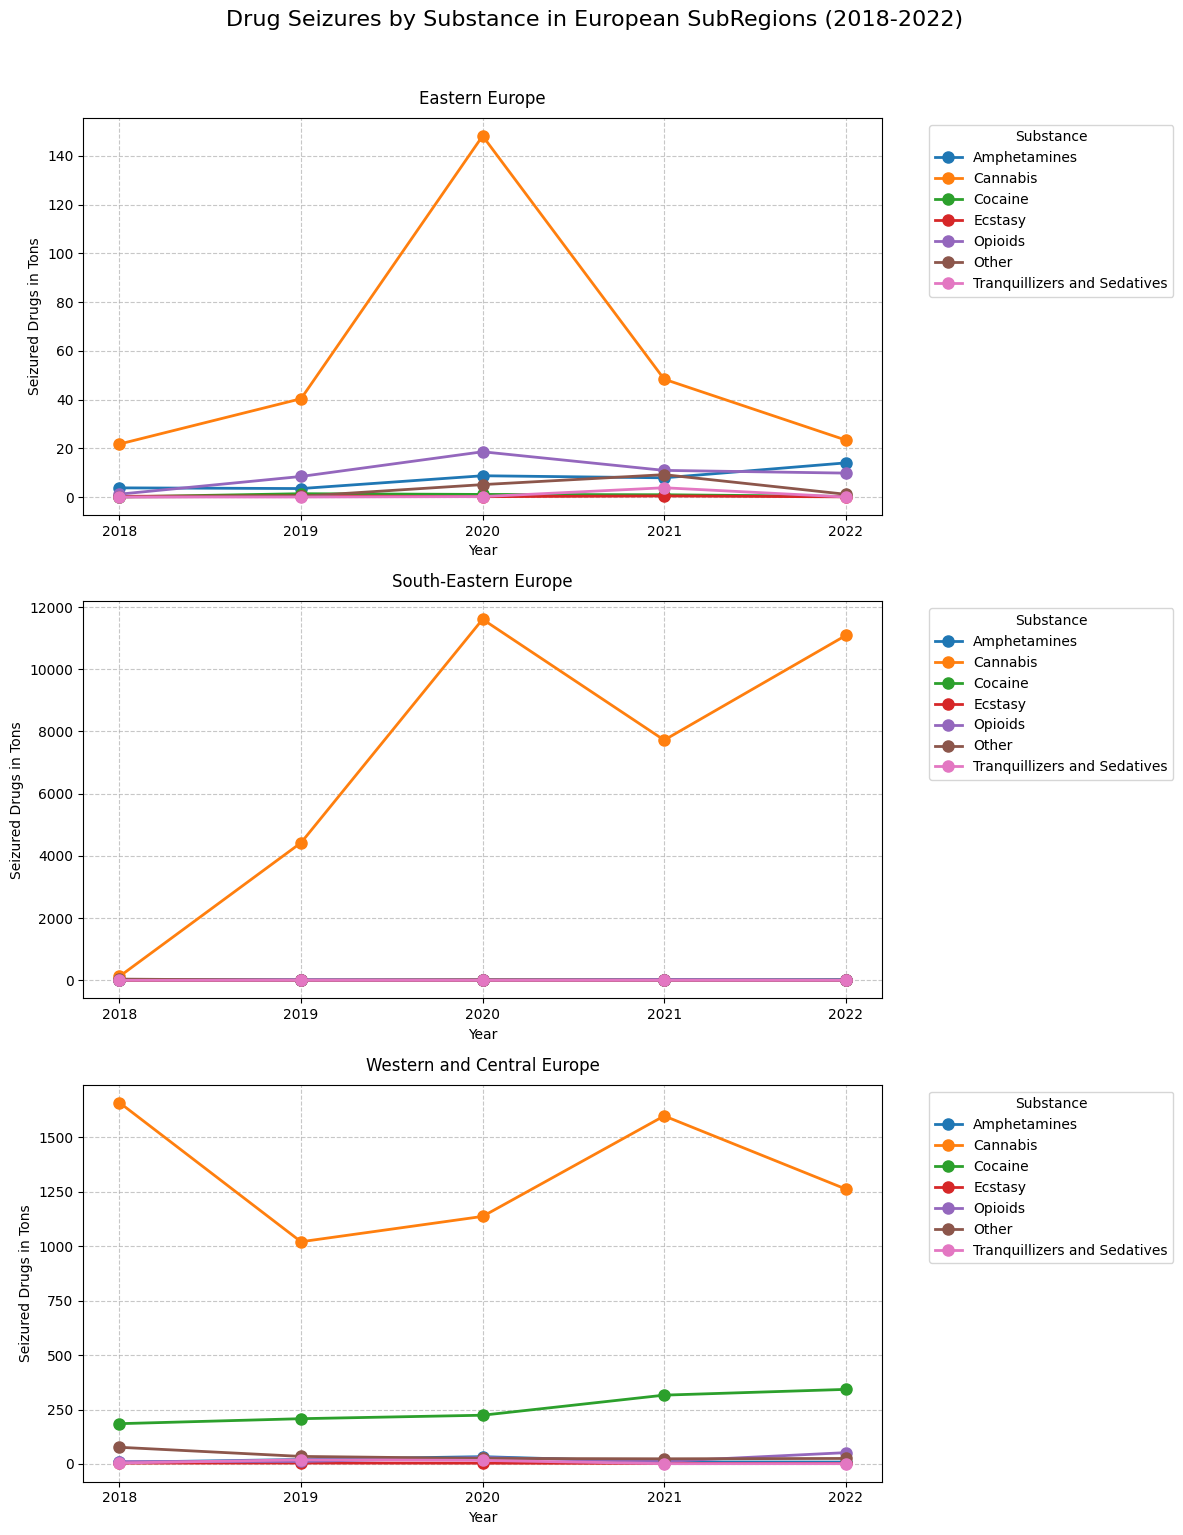

In [168]:
df = drug_seizures_df[['SubRegion','Substance','Year','Kilograms']]
df_grouped = df.groupby(['SubRegion', 'Substance', 'Year']).sum().reset_index()

df_grouped['Tons'] = df_grouped['Kilograms'] / 1000


subregions = df_grouped['SubRegion'].unique()


fig, axes = plt.subplots(len(subregions), 1, figsize=(12, 5*len(subregions)))
fig.suptitle('Drug Seizures by Substance in European SubRegions (2018-2022)', fontsize=16, y=1.02)

colors = plt.cm.Set2(np.linspace(0, 1, len(df_grouped['Substance'].unique())))

for idx, subregion in enumerate(subregions):
    subregion_data = df_grouped[df_grouped['SubRegion'] == subregion]

    pivot_data = subregion_data.pivot(index='Year', columns='Substance', values='Tons')
    
    pivot_data.plot(marker='o', ax=axes[idx], linewidth=2, markersize=8)

    axes[idx].set_title(f'{subregion}', fontsize=12, pad=10)
    axes[idx].set_xlabel('Year', fontsize=10)
    axes[idx].set_ylabel('Seizured Drugs in Tons', fontsize=10)
    axes[idx].grid(True, linestyle='--', alpha=0.7)
    axes[idx].legend(title='Substance', bbox_to_anchor=(1.05, 1), loc='upper left')

    axes[idx].set_xticks(pivot_data.index)
    axes[idx].set_xticklabels(pivot_data.index.astype(int))

plt.tight_layout()
plt.show()

## Combine All Data

In [169]:
# drug_seizures_df drug_prices_df drug_purity_df

In [170]:
drug_prices_join = drug_prices_df[drug_prices_df['Unit']=='Gram'].groupby(['SubRegion', 'Country', 'Substance', 'LevelOfSale', 'Year'], as_index=False)['Typical_USD'].mean()
drug_prices_join = drug_prices_join.set_index(['SubRegion', 'Country', 'Substance', 'Year'])

drug_purity_join = drug_purity_df[drug_purity_df['Measurement']=='% (percent)'].groupby(['SubRegion', 'Country', 'Substance', 'Year'], as_index=False)['Typical'].mean()
drug_purity_join = drug_purity_join.set_index(['SubRegion', 'Country', 'Substance', 'Year'])

drug_seizures_join = drug_seizures_df.groupby(['SubRegion', 'Country', 'Substance', 'Year'], as_index=False)['Kilograms'].sum()
drug_seizures_join = drug_seizures_join.set_index(['SubRegion', 'Country', 'Substance', 'Year'])

drug_data_combined =  drug_purity_join.join(drug_prices_join, how='inner')
drug_data_combined = drug_data_combined.join(drug_seizures_join, how='inner')

display(drug_data_combined)

Typical  \
SubRegion                  Country        Substance    Year            
Eastern Europe             Belarus        Amphetamines 2021  97.0000   
                                          Cannabis     2021  97.0000   
                                          Cocaine      2021  97.0000   
                                          Ecstasy      2021  97.0000   
                                          Opioids      2021  97.0000   
...                                                              ...   
Western and Central Europe United Kingdom Opioids      2022  46.0000   
                                          Other        2018   0.4175   
                                                       2018   0.4175   
                                                       2019   0.4225   
                                                       2019   0.4225   

                                                            LevelOfSale  \
SubRegion                  Country        Substance    Year               
Eastern Europe             Belarus        Amphetamines 2021      Retail   
                                          Cannabis     2021      Retail   
                                          Cocaine      2021      Retail   
                                          Ecstasy      2021      Retail   
                                          Opioids      2021      Retail   
...                                                                 ...   
Western and Central Europe United Kingdom Opioids      2022   Wholesale   
                                          Other        2018      Retail   
                                                       2018   Wholesale   
                                                       2019      Retail   
                                                       2019   Wholesale   

                                                             Typical_USD  \
SubRegion                  Country        Substance    Year                
Eastern Europe             Belarus        Amphetamines 2021    30.000000   
                                          Cannabis     2021    40.000000   
                                          Cocaine      2021   150.000000   
                                          Ecstasy      2021    50.000000   
                                          Opioids      2021   200.000000   
...                                                                  ...   
Western and Central Europe United Kingdom Opioids      2022    15.451174   
                                          Other        2018    50.066756   
                                                       2018     3.204272   
                                                       2019    58.842239   
                                                       2019     4.028838   

                                                              Kilograms  
SubRegion                  Country        Substance    Year              
Eastern Europe             Belarus        Amphetamines 2021     1.82800  
                                          Cannabis     2021    29.00600  
                                          Cocaine      2021     0.00203  
                                          Ecstasy      2021     0.17600  
                                          Opioids      2021     0.40629  
...                                                                 ...  
Western and Central Europe United Kingdom Opioids      2022  1418.55000  
                                          Other        2018   155.00000  
                                                       2018   155.00000  
                                                       2019    69.00000  
                                                       2019    69.00000  

[635 rows x 4 columns]

In [171]:
drug_data_combined.describe()

,Typical,Typical_USD,Kilograms
count,548.000000,511.000000,6.350000e+02
mean,27.235354,41.437965,5.012099e+04
std,26.499071,38.923889,6.569463e+05
min,0.022000,1.180638,0.000000e+00
25%,0.692000,11.766833,3.504270e+01
50%,18.500000,31.485774,2.970007e+02
75%,47.200000,59.141201,2.400000e+03
max,97.000000,279.955207,1.159032e+07



Correlation coefficients for Amphetamines:
Purity vs. Price: 0.22
Purity vs. Kilograms Seized: 0.06
Price vs. Kilograms Seized: -0.09


Correlation coefficients for Cannabis:
Purity vs. Price: 0.35
Purity vs. Kilograms Seized: -0.10
Price vs. Kilograms Seized: -0.01


Correlation coefficients for Cocaine:
Purity vs. Price: 0.03
Purity vs. Kilograms Seized: 0.04
Price vs. Kilograms Seized: -0.26


Correlation coefficients for Ecstasy:
Purity vs. Price: -0.12
Purity vs. Kilograms Seized: -0.06
Price vs. Kilograms Seized: 0.00


Correlation coefficients for Opioids:
Purity vs. Price: 0.22
Purity vs. Kilograms Seized: 0.07
Price vs. Kilograms Seized: -0.13



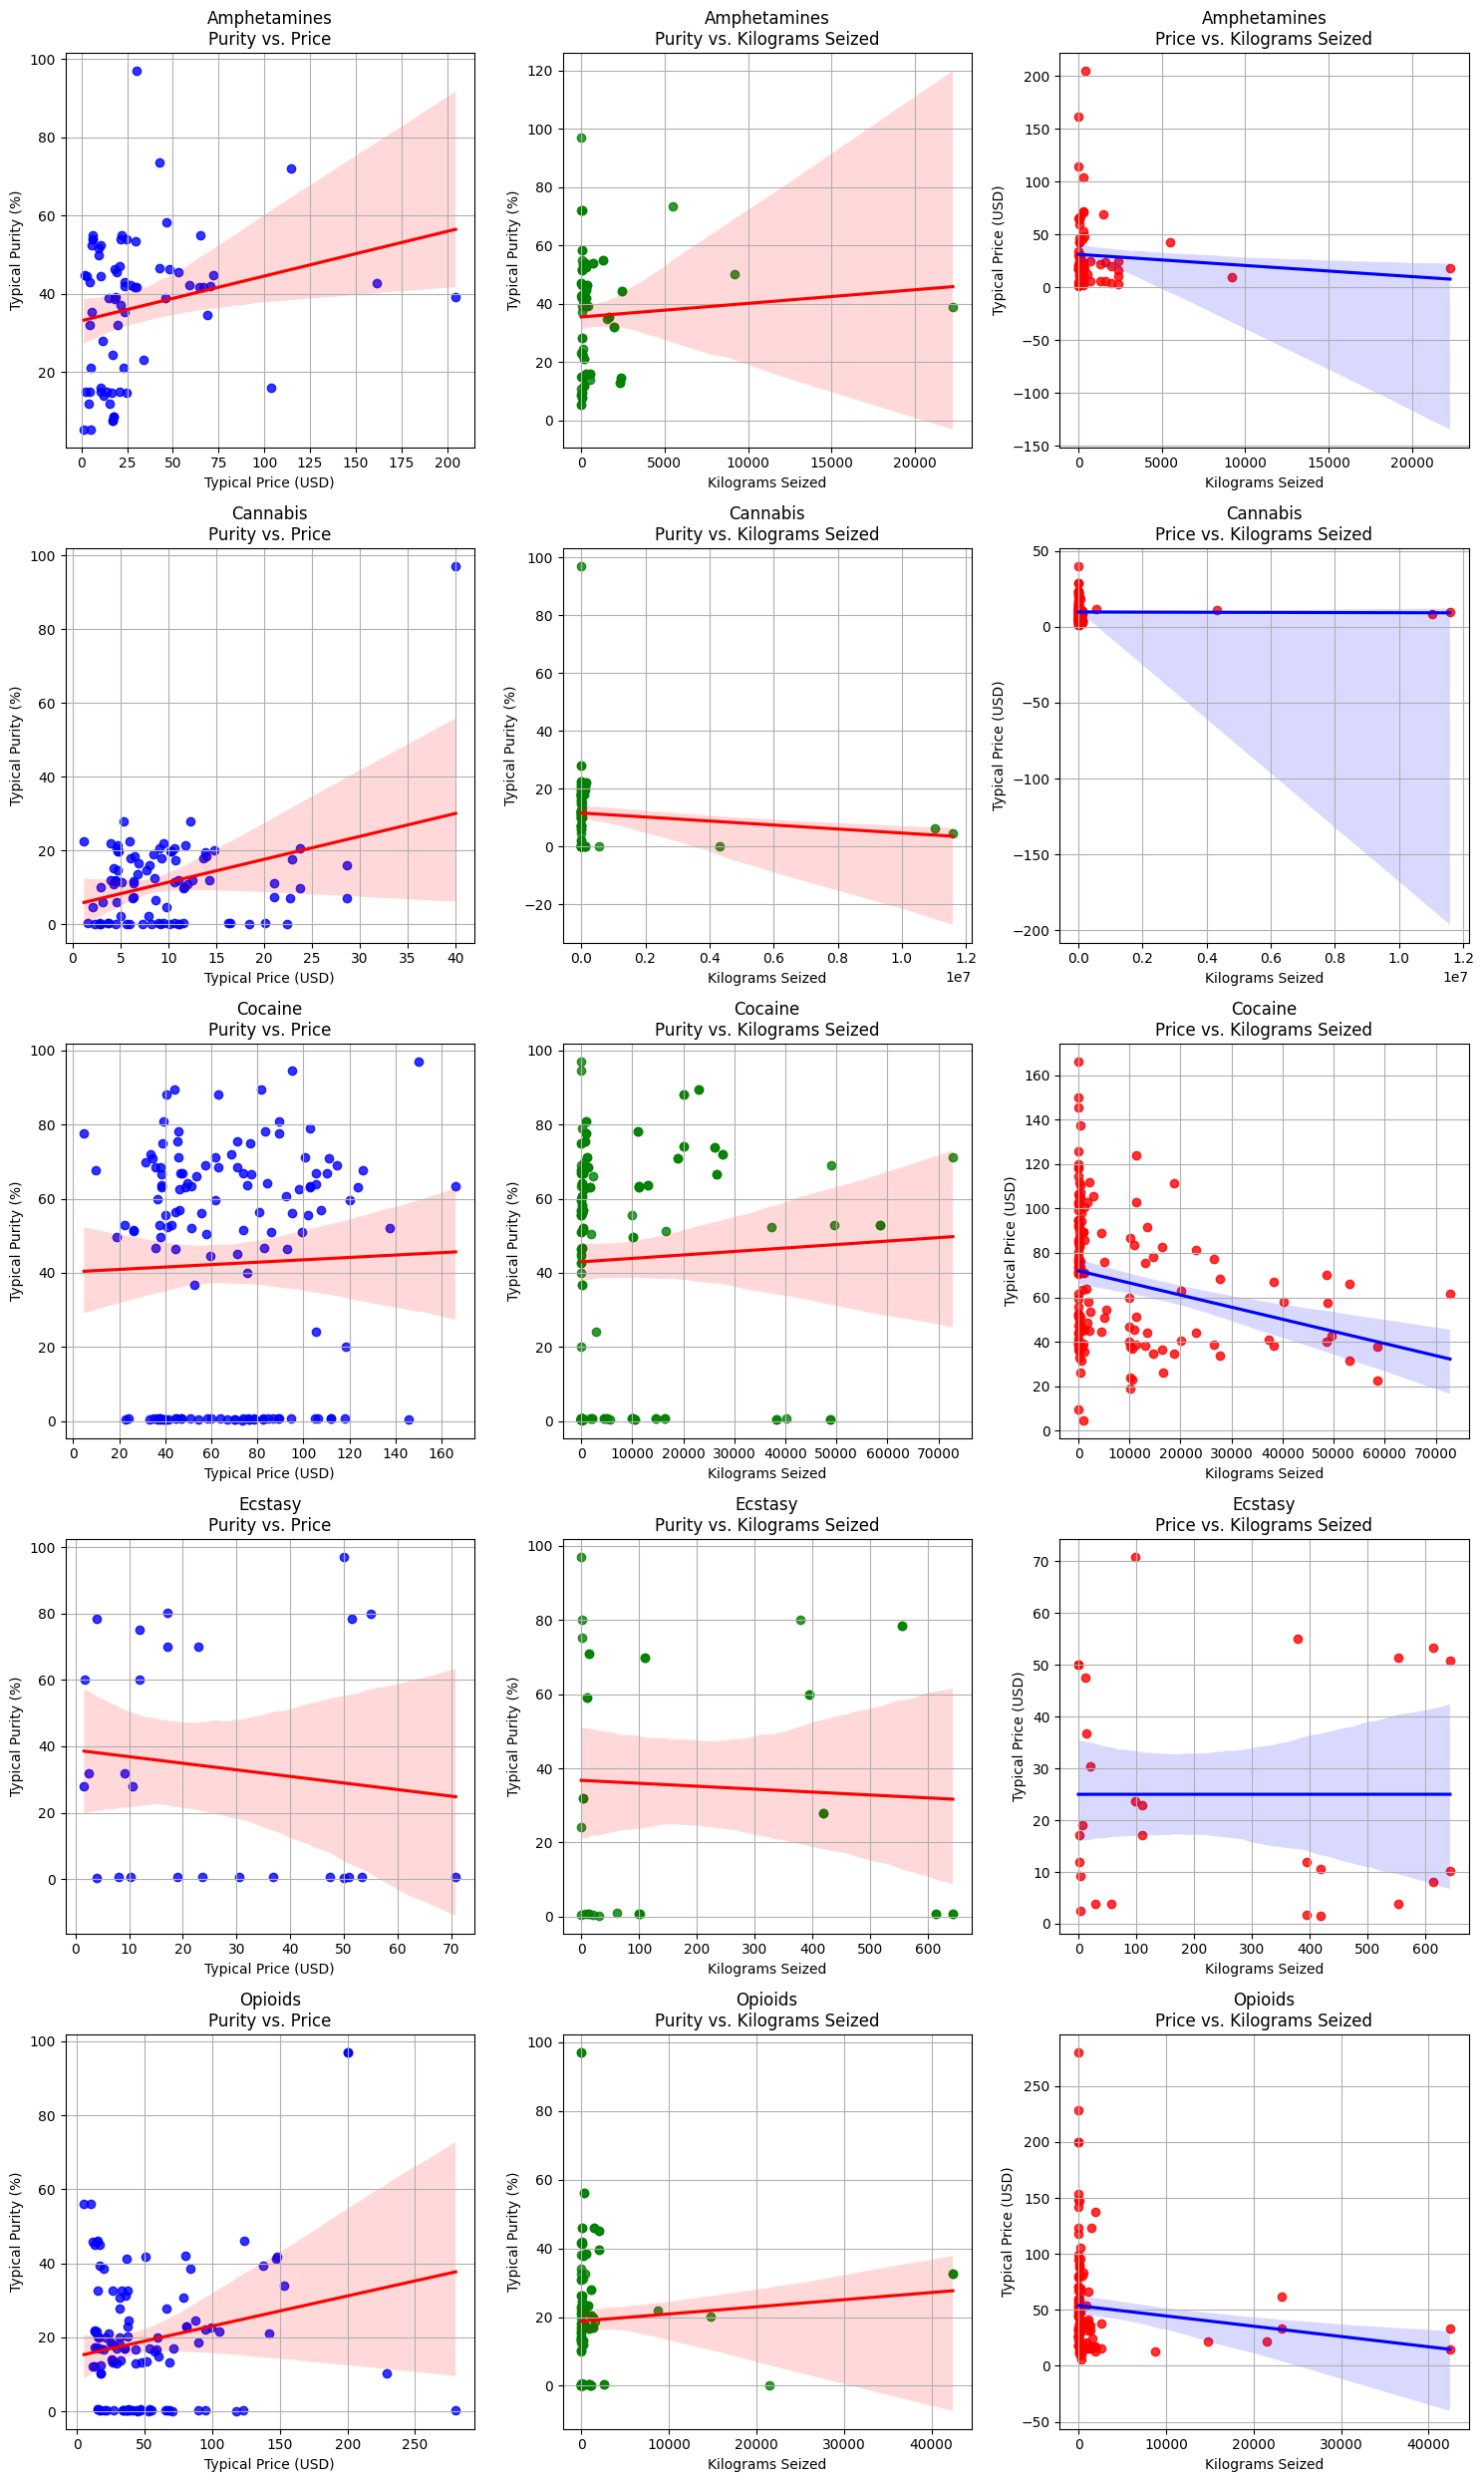

In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


drug_data_combined = drug_data_combined.reset_index()

substances_to_plot = []
for substance in substances:
    subset = drug_data_combined[drug_data_combined['Substance'] == substance]
    if subset.shape[0] >= 2:
        substances_to_plot.append(substance)
    else:
        print(f"Not enough data to plot for substance: {substance}")


num_substances = len(substances_to_plot)
fig, axes = plt.subplots(num_substances, 3, figsize=(15, 5 * num_substances))

if num_substances == 1:
    axes = [axes]


for idx, substance in enumerate(substances_to_plot):
    subset = drug_data_combined[drug_data_combined['Substance'] == substance]
    
    # Purity vs. Price with Regression
    sns.regplot(
        ax=axes[idx][0],
        x='Typical_USD',
        y='Typical',
        data=subset,
        scatter_kws={'color': 'blue'},
        line_kws={'color': 'red'}
    )
    axes[idx][0].set_xlabel('Typical Price (USD)')
    axes[idx][0].set_ylabel('Typical Purity (%)')
    axes[idx][0].set_title(f'{substance}\nPurity vs. Price')
    axes[idx][0].grid(True)
    
    # Purity vs. Kilograms Seized with Regression
    sns.regplot(
        ax=axes[idx][1],
        x='Kilograms',
        y='Typical',
        data=subset,
        scatter_kws={'color': 'green'},
        line_kws={'color': 'red'}
    )
    axes[idx][1].set_xlabel('Kilograms Seized')
    axes[idx][1].set_ylabel('Typical Purity (%)')
    axes[idx][1].set_title(f'{substance}\nPurity vs. Kilograms Seized')
    axes[idx][1].grid(True)
    
    # Price vs. Kilograms Seized with Regression
    sns.regplot(
        ax=axes[idx][2],
        x='Kilograms',
        y='Typical_USD',
        data=subset,
        scatter_kws={'color': 'red'},
        line_kws={'color': 'blue'}
    )
    axes[idx][2].set_xlabel('Kilograms Seized')
    axes[idx][2].set_ylabel('Typical Price (USD)')
    axes[idx][2].set_title(f'{substance}\nPrice vs. Kilograms Seized')
    axes[idx][2].grid(True)
    

    corr_purity_price = subset['Typical_USD'].corr(subset['Typical'])
    corr_purity_kilograms = subset['Kilograms'].corr(subset['Typical'])
    corr_price_kilograms = subset['Kilograms'].corr(subset['Typical_USD'])
    
    print(f"\nCorrelation coefficients for {substance}:")
    print(f"Purity vs. Price: {corr_purity_price:.2f}")
    print(f"Purity vs. Kilograms Seized: {corr_purity_kilograms:.2f}")
    print(f"Price vs. Kilograms Seized: {corr_price_kilograms:.2f}\n")


plt.tight_layout()
plt.show()

Based on these plots the effect of drug seizures on price and purity varies depending on the specific substance:

1. Effect on Price:
For most substances shown (e.g., amphetamines, cocaine, heroin), there appears to be a slight positive correlation between seizures and price. This suggests that increased seizures may lead to higher prices, possibly due to reduced supply.

2. Effect on Purity:
The relationship between seizures and purity is less clear and seems to vary by substance. For some drugs, there's a slight negative correlation, indicating that increased seizures might lead to lower purity. However this trend is not consistent across all substances.

3. Which drugs should be seized:
From a law enforcement perspective, the decision on which drugs to prioritize for seizure should be based on multiple factors, not just price and purity effects. However based solely on the data presented:

- Cocaine shows a strong positive correlation between seizures and price, suggesting that seizures might be effective in disrupting the market.
- Heroin also shows a positive correlation between seizures and price, making it another potential target.
- Amphetamines show mixed results, with some positive correlation to price but less clear effects on purity.
- It was shown that all discussed drug categeories are popular in different eu countries.
- Different countries create Wholesale and Retail markets with different properity.

It's important to note that drug seizure strategies should be part of a comprehensive approach that includes prevention, treatment, and harm reduction. The effectiveness of seizures alone in reducing drug use or associated harms is limited.

Additionally this data provides correlations, not causations. Other factors not shown in these plots (like demand, production changes, or international trade patterns) could also influence price and purity.

Ultimately decisions on drug enforcement strategies should be based on a holistic assessment of public health and safety outcomes not solely on market dynamics.